In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.ticker as ticker

import folium

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 부스팅 라이브러리 로드
import lightgbm as lgb
import xgboost as xgb


In [2]:
# Mac 한글 폰트 설정
plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False)

# 데이터 프레임 조회 시 컬럼 줄임 없애기
pd.set_option('display.max_columns', None)

In [3]:
common_palette = [
    '#E63946', '#1D3557', '#457B9D', '#2A9D8F', '#E76F51', 
    '#9B5DE5', '#F4A261', '#3A86FF', '#06D6A0', '#FFB703', 
    '#6D597A', '#118AB2'
]

def use_palette(num=len(common_palette)):
    return [common_palette[i % len(common_palette)] for i in range(num)]

* 참조 - 빅쿼리 직접 호출 관련

In [4]:
# 빅 쿼리 직접 연결용 - 요금이 무섭기 때문에 csv로 진행 ^_^

# from google.cloud import bigquery

# client = bigquery.Client(project="hangang-park")

# # dbt로 생성된 최종 마트 테이블 조회
# sql = """
#     SELECT * 
#     FROM `hangang-park.hangang_park.mart_joined_table`
# """

# # 판다스 데이터프레임으로 변환
# df = client.query(sql).to_dataframe()

# 🅿️ 한강공원 주차장 EDA

* 분석 대상 범위: <br>
전체 한강공원 주차장은 총 30개소이나, 일별 이용 현황 데이터는 28개소만 집계되고 있습니다.

* 마스터 데이터 활용: <br>
일별 시계열 분석 시 2개 주차장이 제외되므로, 주차장 기본 제원 및 전반적인 특성 파악은 누락이 없는 `park_master 테이블(30개소 전체)`을 기준으로 먼저 진행합니다.

## 데이터 호출

In [5]:
master_df = pd.read_csv('../data/pre_processed/park_master.csv')

In [6]:
# 지구 코드 고유 수 파악
master_df['DSTRCT_TYPE'].nunique() # 11
# 지구 코드 고유 내용 파악
master_df['DSTRCT_TYPE'].unique() # ['강서', '광나루', '난지', '뚝섬', '망원', '반포', '양화', '여의도', '이촌', '잠실', '잠원']

# 주차장 고유 수 파악
master_df['PKLT_TYPE'].nunique() # 30

# 면수
master_df['PRK_CNT'].min() # 20
master_df['PRK_CNT'].max() # 785
# 장애면수
master_df['PWDBS_PRK_CNT'].unique() # [0]
# 정기면수
master_df['PRD_PRK_CNT'].unique() # [0]

# 주중 이용시간 시작
master_df['WD_OPER_BGNG_TM'].unique() # [06:00]
# 주중 이용시간 종료
master_df['WD_OPER_END_TM'].unique() # [23:00]
# 주말 이용시간 시작
master_df['WE_OPER_BGNG_TM'].unique() # [06:00]
# 주중 이용시간 종료
master_df['WE_OPER_END_TM'].unique() # [23:00]

# 면제 시간
master_df['EXMPTN_HR'].unique() # [10, 0]
# 기본 시간
master_df['BSC_HR'].unique() # [30]
# 기본 요금
master_df['BSC_CRG'].unique() # [1000, 2000]
# 간격 시간
master_df['INTR_HR'].unique() # [10]
# 간격 요금
master_df['INTR_CRG'].unique() # [200, 300]
# 전일 요금
master_df['PRVDY_CRG'].unique() # [10000, 15000, 0]
# 주간 요금
master_df['WKLY_CRG'].unique() # [0]
# 야간 요금
master_df['NGHT_CRG'].unique() # [0]
# 정기권 금액
master_df['PRD_AMT'].unique() # [50000, 1000000]
# 주차장 운영업체
master_df['PKLT_OPER_BZENTY'].nunique() # 6

6

* 규모 및 관리 체계: <br>
한강공원 주차장은 총 30개소(11개 지구)로 구성되어 있으며, 6개 위탁 관리 업체가 분할 운영하고 있습니다.

* 주차 면수 특성:
  * 주차 면수는 최소 20면에서 최대 785면까지 규모 편차가 큽니다.
  * 별도의 장애인 전용 구획이나 정기권 전용 면수는 할당되어 있지 않습니다.


* 운영 시간: <br>
평일과 주말 구분 없이 전 구역 06:00 ~ 23:00 동일하게 운영됩니다.

* 요금 체계:
  * 주·야간 구분 요금 없이 기본요금, 추가(간격)요금, 전일 주차요금 3가지 체계로 구성됩니다.
  * 요금 부과 기준 시간(기본 시간 및 추가 간격)은 모든 주차장이 동일하나, 주차장별 적용 단가(금액)에는 차이가 있습니다.

## 주차장 별 규모 파악
* 각 주차장이 보유한 주차면수를 기준으로 규모를 파악합니다.

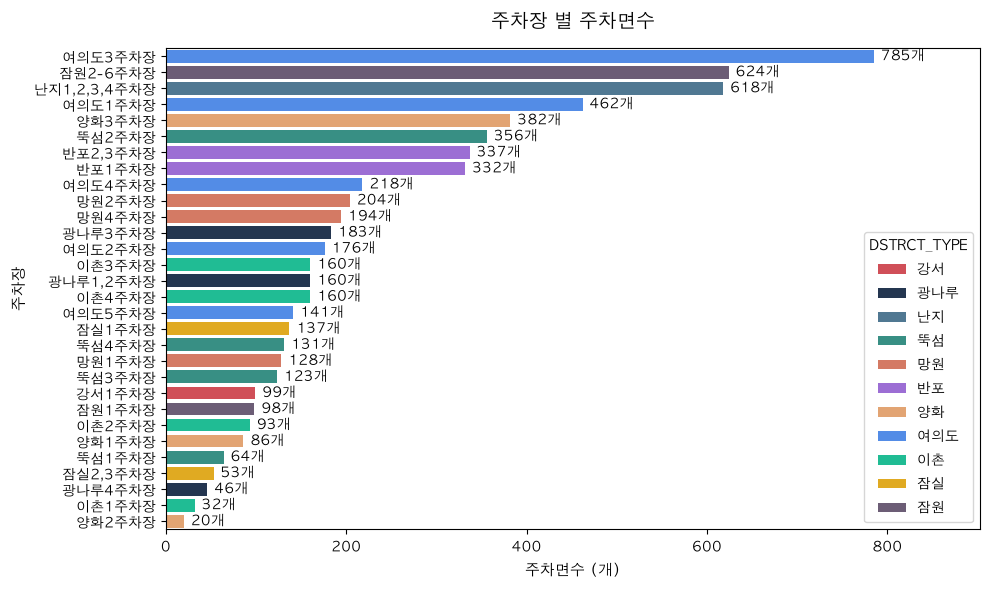

In [7]:
sorted_order = master_df.sort_values(by='PRK_CNT', ascending=False)['PKLT_TYPE']

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=master_df,
    x='PRK_CNT',
    y='PKLT_TYPE',
    order=sorted_order,  # 정렬 기준 전달
    hue='DSTRCT_TYPE',
    palette=use_palette(11),
    legend=True
)

# 막대 오른쪽에 수치 라벨 추가
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f'{int(width)}개',
            xy=(width, p.get_y() + p.get_height() / 2),
            xytext=(5, 0),
            textcoords="offset points",
            ha='left',
            va='center',
            fontsize=10
        )

plt.title('주차장 별 주차면수', fontsize=14, pad=15)
plt.xlabel('주차면수 (개)', fontsize=11)
plt.ylabel('주차장', fontsize=11)

# 레이블이 잘리지 않도록 x축 오른쪽 여백 살짝 확장
ax.set_xlim(0, master_df['PRK_CNT'].max() * 1.15)

plt.tight_layout()
plt.show()

* '여의도 3주차장'의 주차면수는 785개로 가장 많은 면수를 확보하고 있으며, <br>
'난지 1,2,3,4 주차장 (618개)'이 뒤를 잇고 있습니다.

* 다만, 주차장명으로 미루어 볼 때 '난지 1,2,3,4' 주차장은 4개의 개별 주차공간이 통합 집계되었을 가능성이 있습니다.

## 지구별 주차장 위치 확인

In [8]:
# 1. 컬럼명 지정
lat_col = 'PSTN_INFO_LAT'
lon_col = 'PSTN_INFO_LOT'
district_col = 'DSTRCT_TYPE'

# 2. 주차장 단위 중복 제거 및 결측치 제거
parking_map_df = master_df[['PKLT_TYPE', 'PKLT_OPER_BZENTY', district_col, lat_col, lon_col]].drop_duplicates(subset=['PKLT_TYPE']).dropna(subset=[lat_col, lon_col])

# 3. 한강 중심 좌표로 기본 지도 생성
m = folium.Map(
    location=[37.5300, 126.9800],
    zoom_start=11,
    tiles='cartodbpositron',
    scrollWheelZoom=False
)

# 4. 지구별 고유 색상 팔레트 정의
districts = parking_map_df[district_col].dropna().unique()
palette_ = use_palette(11)
color_map = {dist: palette_[i % len(palette_)] for i, dist in enumerate(districts)}

# 5. 지구별 레이어(FeatureGroup) 생성 및 마커 추가
for dist in districts:
    fg = folium.FeatureGroup(name=f"📍 {dist}")
    dist_df = parking_map_df[parking_map_df[district_col] == dist]
    
    for _, row in dist_df.iterrows():
        folium.CircleMarker(
            location=[row[lat_col], row[lon_col]],
            radius=7,
            popup=folium.Popup(
                f"<b>{row['PKLT_TYPE']}</b><br>"
                f"<span style='color:gray;'>지구:</span> {row[district_col]}<br>"
                f"<span style='color:gray;'>운영사:</span> {row['PKLT_OPER_BZENTY']}",
                max_width=220
            ),
            tooltip=f"{row['PKLT_TYPE']} ({row[district_col]})",
            color='#ffffff',
            weight=1.5,
            fill=True,
            fill_color=color_map[dist],
            fill_opacity=0.85
        ).add_to(fg)
    
    fg.add_to(m)

# 6. 우측 상단 고정 범례(Legend) HTML 추가
legend_items = "".join([
    f"<li style='margin-bottom: 3px;'><span style='background:{color_map[d]}; width:11px; height:11px; display:inline-block; border-radius:50%; margin-right:6px;'></span>{d}</li>"
    for d in districts
])

legend_html = f'''
<div style="
    position: fixed; 
    top: 25px; right: 25px; width: 180px; 
    max-height: 400px;
    overflow-y: auto;
    background-color: rgba(255, 255, 255, 0.95);
    border: 1px solid #ccc;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.2);
    border-radius: 8px;
    z-index: 9999; 
    font-size: 11px;
    font-family: sans-serif;
    padding: 10px 14px;
">
    <div style="font-weight: bold; margin-bottom: 8px; font-size: 12px;">📌 한강공원 지구</div>
    <ul style="list-style: none; padding-left: 0; margin: 0; line-height: 1.4;">
        {legend_items}
    </ul>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# 7. 출력
m

* 지구는 각 주차장의 상위 분류 체계로, 지구별 특성과 입지에 맞춰 주차장이 밀집되어 분포하는 형태를 보입니다.

## 각 지구별 주차장 규모 파악
* 개별 주차장마다 1개소 또는 여러 개소의 면수가 통합 집계되어 있고, 주차장이 지구 단위로 군집을 이루고 있으므로 지구별 총 주차장 규모(총 주차면수 및 주차장 개소 수)를 집계하여 파악합니다.

In [9]:
dstrct_summary = master_df.groupby('DSTRCT_TYPE').agg(
    dstrct_park_count=('PRK_CNT', 'sum')
).reset_index().sort_values(by='dstrct_park_count', ascending=False)

display(dstrct_summary)

,DSTRCT_TYPE,dstrct_park_count
7,여의도,1782
10,잠원,722
3,뚝섬,674
5,반포,669
2,난지,618
4,망원,526
6,양화,488
8,이촌,445
1,광나루,389
9,잠실,190


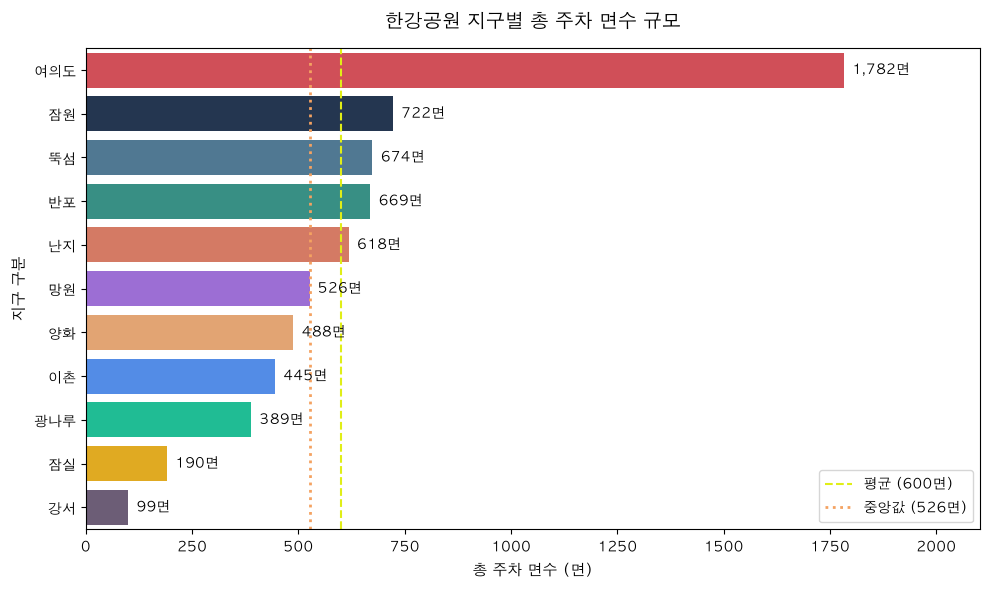

In [10]:
plt.figure(figsize=(10, 6))

# 1. 평균 및 중앙값 계산
mean_count = dstrct_summary['dstrct_park_count'].mean()
median_count = dstrct_summary['dstrct_park_count'].median()

# 2. 가로 막대 그래프 생성
ax = sns.barplot(
    data=dstrct_summary,
    x='dstrct_park_count',
    y='DSTRCT_TYPE',
    hue='DSTRCT_TYPE',
    palette=use_palette(11),
    legend=False
)

# 3. 평균선 및 중앙값선 추가
ax.axvline(
    x=mean_count,
    color="#E0EE17",
    linestyle='--',
    linewidth=1.5,
    label=f'평균 ({mean_count:,.0f}면)'
)
ax.axvline(
    x=median_count,
    color='#F4A261',
    linestyle=':',
    linewidth=2.0,
    label=f'중앙값 ({median_count:,.0f}면)'
)

# 4. 막대 우측 수치 라벨 추가
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f'{int(width):,}면',
            xy=(width, p.get_y() + p.get_height() / 2),
            xytext=(6, 0),
            textcoords="offset points",
            ha='left',
            va='center',
            fontsize=10
        )

plt.title('한강공원 지구별 총 주차 면수 규모', fontsize=14, pad=15)
plt.xlabel('총 주차 면수 (면)', fontsize=11)
plt.ylabel('지구 구분', fontsize=11)

# 범례 표시 및 오른쪽 여백 확장
plt.legend(loc='lower right', frameon=True)
ax.set_xlim(0, dstrct_summary['dstrct_park_count'].max() * 1.18)

plt.tight_layout()
plt.show()

* 여의도 지구는 다른 지구에 비해 압도적으로 많은 주차면수를 확보하고 있습니다.

* 반면 양화, 이촌, 광나루, 잠실, 강서 지구는 상대적으로 주차면수가 부족한 편입니다.

## 주차장 별 요금 파악
* 주차장별 요금 관련 데이터에서 일부 차이가 존재함을 확인하였습니다.

* 공공에서 운영하는 한강공원 주차장 간에 실제 요금 차등이 존재하는지 점검하고, 특히 전일 요금이 '0원'으로 기록된 항목은 이상치(결측/오류)일 가능성이 높아 요금 항목을 중심으로 세부 확인을 진행합니다.

In [11]:
# 요금관련 컬럼 정의 (차이가 발생한)
diff_fee_cols = [ 'EXMPTN_HR', 'BSC_CRG', 'INTR_CRG', 'PRVDY_CRG', 'PRD_AMT' ]

# 주차장명(또는 식별 컬럼)과 함께 확인
cols_to_show = ['PKLT_TYPE'] + diff_fee_cols

master_df[cols_to_show].drop_duplicates().reset_index(drop=True)

,PKLT_TYPE,EXMPTN_HR,BSC_CRG,INTR_CRG,PRVDY_CRG,PRD_AMT
0,강서1주차장,10,1000,200,10000,50000
1,"광나루1,2주차장",10,1000,200,10000,50000
2,광나루3주차장,10,1000,200,10000,50000
3,광나루4주차장,10,1000,200,10000,50000
4,"난지1,2,3,4주차장",10,1000,200,10000,50000
5,뚝섬1주차장,10,1000,200,10000,50000
6,뚝섬2주차장,10,1000,200,10000,50000
7,뚝섬3주차장,10,1000,200,10000,50000
8,뚝섬4주차장,10,1000,200,10000,50000
9,망원1주차장,10,1000,200,10000,50000


* 이상치 발견: <br>
데이터 탐색 과정에서 일부 주차장의 면제시간 및 전일 요금이 0원으로 집계되는 현상을 확인하였습니다.

* 교차 검증 (Cross-Check):<br>
한강사업본부 공식 웹사이트를 통해 실제 주차장 운영 정보를 직접 대조한 결과, 해당 주차장의 고유 정책이 아닌 데이터 단순 누락/오류로 확인되었습니다.
  * 잠원 한강공원 주차정보: 잠원 2~6주차장 면제시간 10분 적용<br>
  (https://hangang.seoul.go.kr/www/contents/748.do?mid=456)
  * 여의도 한강공원 주차정보: 여의도 2주차장 전일 요금 15,000원 적용<br>
  (https://hangang.seoul.go.kr/www/contents/752.do?mid=475)

* 정제 방향:<br>
공식 기준에 맞추어 해당 결측/이상치 데이터를 정상값으로 대체합니다.

In [12]:
# 값 대체 작업 진행
# 1. 잠원 2-6 주차장 면제시간(EXMPTN_HR) -> 10분으로 대체
master_df.loc[master_df['PKLT_TYPE'] == '잠원2-6주차장', 'EXMPTN_HR'] = 10

# 2. 여의도 2주차장 전일 요금(PRVDY_CRG) -> 15,000원으로 대체
master_df.loc[master_df['PKLT_TYPE'] == '여의도2주차장', 'PRVDY_CRG'] = 15000

In [13]:
# 변경 확인 진행
master_df[cols_to_show].drop_duplicates().reset_index(drop=True)

,PKLT_TYPE,EXMPTN_HR,BSC_CRG,INTR_CRG,PRVDY_CRG,PRD_AMT
0,강서1주차장,10,1000,200,10000,50000
1,"광나루1,2주차장",10,1000,200,10000,50000
2,광나루3주차장,10,1000,200,10000,50000
3,광나루4주차장,10,1000,200,10000,50000
4,"난지1,2,3,4주차장",10,1000,200,10000,50000
5,뚝섬1주차장,10,1000,200,10000,50000
6,뚝섬2주차장,10,1000,200,10000,50000
7,뚝섬3주차장,10,1000,200,10000,50000
8,뚝섬4주차장,10,1000,200,10000,50000
9,망원1주차장,10,1000,200,10000,50000


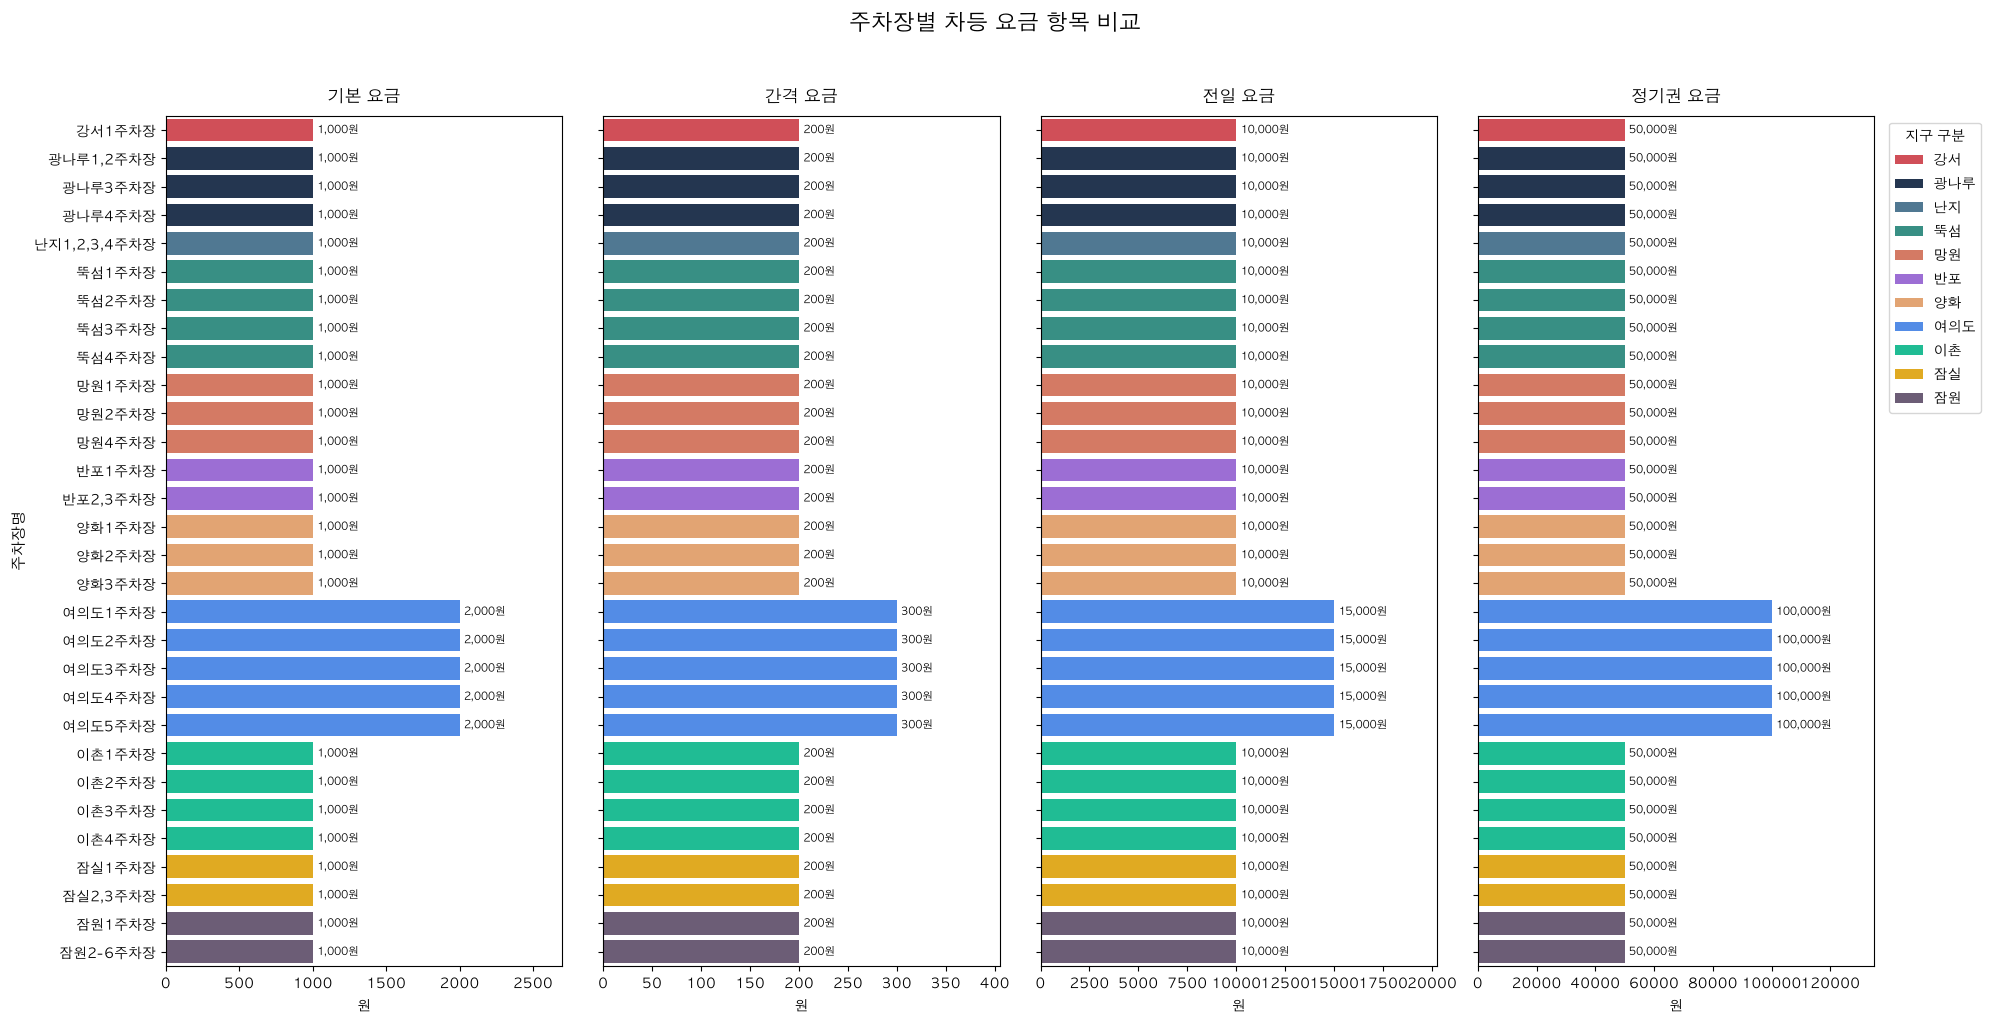

In [14]:
# 면제 시간은 값 대체 후 모두 동일 확인
diff_fee_cols = ['BSC_CRG', 'INTR_CRG', 'PRVDY_CRG', 'PRD_AMT']

fig, axes = plt.subplots(1, len(diff_fee_cols), figsize=(20, 10), sharey=True)

col_info = {
    'BSC_CRG': ('기본 요금', '원'),
    'INTR_CRG': ('간격 요금', '원'),
    'PRVDY_CRG': ('전일 요금', '원'),
    'PRD_AMT': ('정기권 요금', '원')
}

sorted_df = master_df.sort_values(by='PKLT_TYPE')

for i, (ax, col) in enumerate(zip(axes, diff_fee_cols)):
    title, unit = col_info.get(col, (col, ''))
    
    # 마지막 서브플롯에서만 범례 생성 (중복 방지)
    is_last = (i == len(diff_fee_cols) - 1)
    
    sns.barplot(
        data=sorted_df,
        x=col,
        y='PKLT_TYPE',
        ax=ax,
        hue='DSTRCT_TYPE',
        palette=use_palette(sorted_df['DSTRCT_TYPE'].nunique()),
        legend=is_last  # 마지막 플롯만 범례 켜기
    )
    
    # 막대 끝에 수치 라벨 표기 (0원 더미 막대 제외)
    for p in ax.patches:
        width = p.get_width()
        if width > 0:  # 너비가 0보다 큰 실제 데이터 막대만 라벨링
            ax.annotate(
                f'{int(width):,}{unit}',
                xy=(width, p.get_y() + p.get_height() / 2),
                xytext=(3, 0),
                textcoords="offset points",
                ha='left',
                va='center',
                fontsize=8
            )
    
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(unit, fontsize=10)
    ax.set_ylabel('' if ax != axes[0] else '주차장명', fontsize=11)
    ax.set_xlim(0, sorted_df[col].max() * 1.35)

    # 마지막 서브플롯 범례 커스텀 (제목 지정 및 차트 밖 오른쪽으로 이동)
    if is_last:
        sns.move_legend(
            ax,
            "upper left",
            bbox_to_anchor=(1.02, 1),
            title="지구 구분",
            frameon=True
        )

plt.suptitle('주차장별 차등 요금 항목 비교', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

* 여의도 지구를 제외한 모든 한강공원 주차장은 동일한 요금 체계를 적용받고 있습니다.
* 반면 여의도 주차장은 다른 주차장에 비해 기본·간격·전일·정기권 등 모든 요금 항목이 약 1.5배에서 2배가량 높게 책정되어 있음을 확인하였습니다.

## 업체별 담당 주차장 수 파악

In [15]:
oper_summary = master_df.groupby('PKLT_OPER_BZENTY').agg(
    parking_lot_count=('PKLT_TYPE', 'nunique')
).reset_index().sort_values(by='parking_lot_count', ascending=False)

display(oper_summary)

,PKLT_OPER_BZENTY,parking_lot_count
1,(주)케이엠파크,15
0,(주)씨앤에스자산관리_양화_강서,4
3,공우이엔씨(주)_뚝섬,4
5,리스크테크(주),4
2,(주)하이파킹,2
4,공우이엔씨(주)_여의도_3,1


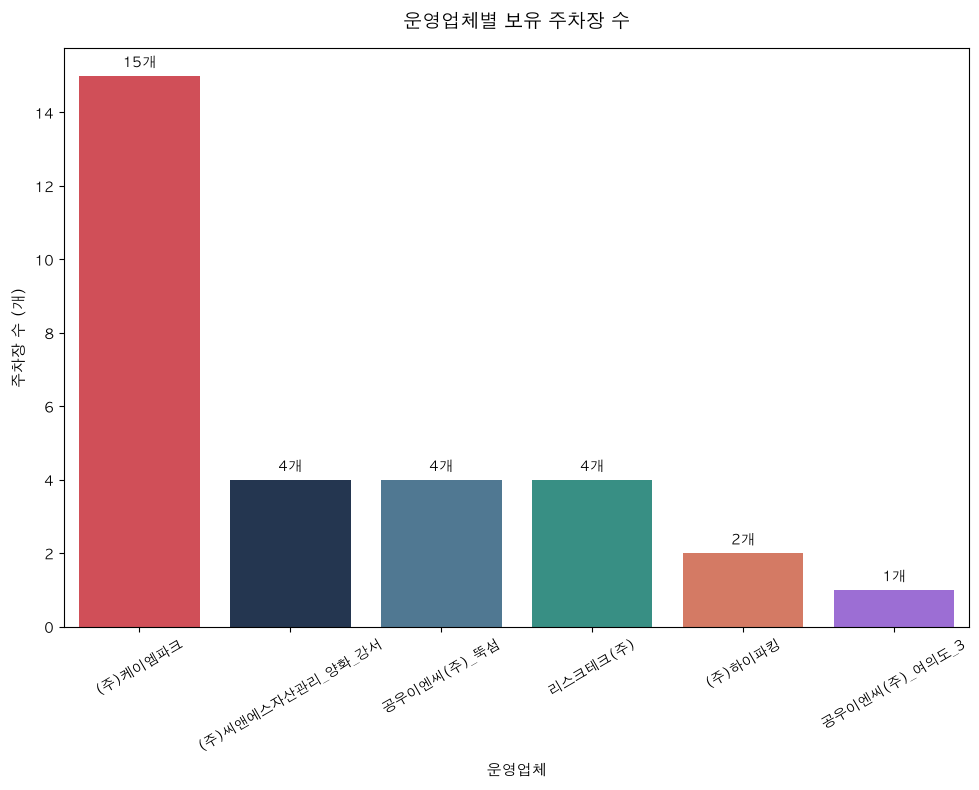

In [16]:
plt.figure(figsize=(10, 8))
ax = sns.barplot(
    data=oper_summary,
    x='PKLT_OPER_BZENTY',
    y='parking_lot_count',
    hue='PKLT_OPER_BZENTY',  # 최신 seaborn 문법 적용
    palette=use_palette(6),
    legend=False             # 범례 숨김
)

# 막대 위에 수치 라벨 추가
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}개',
            xy=(p.get_x() + p.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.title('운영업체별 보유 주차장 수', fontsize=14, pad=15)
plt.xlabel('운영업체', fontsize=11)
plt.ylabel('주차장 수 (개)', fontsize=11)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

* 현재 한강공원 주차장 위탁 관리는 총 6개 전문 업체가 분할 운영하고 있습니다.
* 그중 '(주)케이엠파크'가 전체 한강공원 주차장의 50%를 위탁 관리하며 가장 높은 점유율을 차지하고 있습니다.

## 업체별 담당 주차장 위치 확인

In [17]:
# 1. 위경도 컬럼명 지정
lat_col = 'PSTN_INFO_LAT'
lon_col = 'PSTN_INFO_LOT'

# 2. 주차장 단위 중복 제거 및 결측치 제거
parking_map_df = master_df[['PKLT_TYPE', 'PKLT_OPER_BZENTY', lat_col, lon_col]].drop_duplicates(subset=['PKLT_TYPE']).dropna(subset=[lat_col, lon_col])

# 3. 한강 중심 좌표로 기본 지도 생성 (깔끔한 CartoDB Positron 배경)
m = folium.Map(
    location=[37.5700, 126.9800],
    zoom_start=11,
    tiles='cartodbpositron',
    scrollWheelZoom=False
)

# 4. 운영 업체별 고유 색상 팔레트 정의
operators = parking_map_df['PKLT_OPER_BZENTY'].dropna().unique()
palette_ = use_palette(6)
color_map = {oper: palette_[i % len(palette_)] for i, oper in enumerate(operators)}

# 5. 업체별 레이어(FeatureGroup) 생성 및 점(CircleMarker) 추가
for oper in operators:
    fg = folium.FeatureGroup(name=f"🏢 {oper}")
    oper_df = parking_map_df[parking_map_df['PKLT_OPER_BZENTY'] == oper]
    
    for _, row in oper_df.iterrows():
        folium.CircleMarker(
            location=[row[lat_col], row[lon_col]],
            radius=7,
            popup=folium.Popup(f"<b>{row['PKLT_TYPE']}</b><br><span style='color:gray;'>운영사:</span> {row['PKLT_OPER_BZENTY']}", max_width=220),
            tooltip=f"{row['PKLT_TYPE']} ({row['PKLT_OPER_BZENTY']})",
            color='#ffffff',               # 테두리 흰색 (가독성 향상)
            weight=1.5,
            fill=True,
            fill_color=color_map[oper],     # 업체별 색상 적용
            fill_opacity=0.85
        ).add_to(fg)
    
    fg.add_to(m)

# 6. 지도 우측 상단에 레이어 켜기/끄기 컨트롤 추가
# folium.LayerControl(collapsed=False).add_to(m)

# 7. 좌측 하단 고정 범례(Legend) HTML 추가
legend_items = "".join([
    f"<li><span style='background:{color_map[op]}; width:12px; height:12px; display:inline-block; border-radius:50%; margin-right:6px;'></span>{op}</li>"
    for op in operators
])

legend_html = f'''
<div style="
    position: fixed; 
    top: 25px; right: 25px; width: 300px; 
    background-color: rgba(255, 255, 255, 0.9);
    border: 1px solid #ccc;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.2);
    border-radius: 8px;
    z-index: 9999; 
    font-size: 10px;
    font-family: sans-serif;
    padding: 10px 14px;
">
    <div style="font-weight: bold; margin-bottom: 6px; font-size: 13px;">📌 운영 업체 범례</div>
    <ul style="list-style: none; padding-left: 0; margin: 0; line-height: 1.6;">
        {legend_items}
    </ul>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# 8. 주피터 노트북에서 바로 출력
m

* 지역 기반 위탁 운영: <br>
개별 주차장 단위가 아닌, 특정 권역/지역 단위로 구역을 묶어 관리하는 경향이 보입니다.

* 관리 구역 집중도: <br>
각 업체별 담당 주차장은 지리적으로 인접하게 밀집되어 있으며, 가장 많은 주차장을 위탁 운영하는 (주)케이엠파크 역시 '서울 중심'과 '동부권'에 집중되어 있습니다.

# 🅿️ 한강공원 주차장 이용량 EDA 

* 기 구축된 일별 주차 이용 현황 데이터 마트를 기반으로 탐색적 데이터 분석(EDA)을 수행합니다.
* 단, 본 분석 대상은 일별 이용 데이터가 정상 집계된 총 28개 주차장이며, 일별 집계가 누락된 `망원 4주차장` 및 `이촌 4주차장` 2개소는 분석 대상에서 제외되었습니다.

## 데이터 호출

In [18]:
df = pd.read_csv('../data/final_dataset/bq-results-20260825-092945-1787650226335.csv')

df.head(2)

,DSTRCT_CODE,PKLT_NM,PRK_CNTOM,UTZTN_HR,DT,DSTRCT_TYPE,PKLT_TYPE,PSTN_INFO_LAT,PSTN_INFO_LOT,PRK_CNT,PWDBS_PRK_CNT,PRD_PRK_CNT,WD_OPER_BGNG_TM,WD_OPER_END_TM,WE_OPER_BGNG_TM,WE_OPER_END_TM,EXMPTN_HR,BSC_HR,BSC_CRG,INTR_HR,INTR_CRG,PRVDY_CRG,WKLY_CRG,NGHT_CRG,PRD_AMT,PKLT_OPER_BZENTY,is_holiday,temp,precip
0,PLT-001,강서1주차장,234,14721,2026-04-28,강서,강서1주차장,37.585709,126.818279,99,0,0,06:00,23:00,06:00,23:00,10,30,1000,10,200,10000,0,0,50000,(주)씨앤에스자산관리_양화_강서,False,13.3,0.2
1,PLT-001,강서1주차장,179,6974,2026-02-13,강서,강서1주차장,37.585709,126.818279,99,0,0,06:00,23:00,06:00,23:00,10,30,1000,10,200,10000,0,0,50000,(주)씨앤에스자산관리_양화_강서,False,5.3,0.0


* 데이터 프레임 컬럼 설명 (호출 데이터 기준)

| 컬럼명 | 컬럼 설명 | 비고 | 
| - | - | - |
| DSTRCT_CODE | 지구 코드 | |
| PKLT_NM | 주차장 이름| |
| PRK_CNTOM | 주차대수 | |
| UTZTN_HR | 주차 시간 | |
| PKLT_TYPE | 주차장 이름 | |
| PSTN_INFO_LAT | 위도 | |
| PSTN_INFO_LOT | 경도 | |
| PRK_CNT | 면수 | |
| PWDBS_PRK_CNT | 장애면수 | |
| PRD_PRK_CNT | 정기면수 | |
| WD_OPER_BGNG_TM | 주중 이용시간 시작 | |
| WD_OPER_END_TM | 주중 이용시간 종료 | |
| WE_OPER_BGNG_TM | 주말 이용시간 시작 | |
| WE_OPER_END_TM | 주말 이용시간 종료 | |
| EXMPTN_HR | 면제 시간 | |
| BSC_HR | 기본 시간 | |
| BSC_CRG | 기본 요금 | |
| INTR_HR | 간격 시간 | |
| INTR_CRG | 간격 요금 | |
| PRVDY_CRG | 전일 요금 | |
| WKLY_CRG | 주간 요금 | |
| NGHT_CRG | 야간 요금 | |
| PRD_AMT | 정기권 금액 | |
| PKLT_OPER_BZENTY | 주차장 운영업체 | |
| is_holiday | 공휴일 여부 | |
| temp | 평균 온도 (°C) | |
| precip | 일 강수량 (mm) | |

## 전처리

### 1차 전처리: 중복 컬럼 제거 및 시계열 기준 재정렬
* 중복/불필요 컬럼 정리:<br>
지구명 및 주차장명과 의미가 중복되는 DSTRCT_CODE(지구 코드) 및 PKLT_TYPE(주차장 유형/구분) 컬럼을 제거합니다.

* 시계열 기준 정렬:<br>
일별 시계열 분석 흐름에 맞추어 DT(일자) 컬럼을 데이터프레임의 최좌측(맨 앞)으로 재배치하고, 날짜 및 주차장명 기준으로 데이터를 오름차순 정렬합니다.

In [19]:
# 지구 구분 코드
df['DSTRCT_CODE'].nunique() # 11
# 지구 구분 이름
df['DSTRCT_TYPE'].nunique() # 11

# 특정 컬럼 삭제 (존재하지 않아도 에러 안 나게 errors='ignore' 설정)
df = df.drop(columns=['DSTRCT_CODE', 'PKLT_TYPE'], errors='ignore')

# 'DT' 컬럼을 맨 앞으로 이동하여 컬럼 재정렬
if 'DT' in df.columns:
    other_cols = [col for col in df.columns if col != 'DT']
    df = df[['DT'] + other_cols]

# 'DT' 컬럼을 datetime으로 변환 후 오름차순 정렬 (내림차순은 ascending=False)
df['DT'] = pd.to_datetime(df['DT'])
df = df.sort_values(by='DT').reset_index(drop=True)

# 확인
df.head(2)

,DT,PKLT_NM,PRK_CNTOM,UTZTN_HR,DSTRCT_TYPE,PSTN_INFO_LAT,PSTN_INFO_LOT,PRK_CNT,PWDBS_PRK_CNT,PRD_PRK_CNT,WD_OPER_BGNG_TM,WD_OPER_END_TM,WE_OPER_BGNG_TM,WE_OPER_END_TM,EXMPTN_HR,BSC_HR,BSC_CRG,INTR_HR,INTR_CRG,PRVDY_CRG,WKLY_CRG,NGHT_CRG,PRD_AMT,PKLT_OPER_BZENTY,is_holiday,temp,precip
0,2025-08-23,여의도3주차장,1810,237539,여의도,37.532383,126.923676,785,0,0,06:00,23:00,06:00,23:00,10,30,2000,10,300,15000,0,0,100000,공우이엔씨(주)_여의도_3,False,29.3,0.0
1,2025-08-23,강서1주차장,347,24337,강서,37.585709,126.818279,99,0,0,06:00,23:00,06:00,23:00,10,30,1000,10,200,10000,0,0,50000,(주)씨앤에스자산관리_양화_강서,False,29.3,0.0


In [20]:
# 결측값 확인
df.isna().sum().sum() # 0

# 중복값 확인
df.duplicated().sum() # 0

# 통계량 확인
df.describe()

,DT,PRK_CNTOM,UTZTN_HR,PSTN_INFO_LAT,PSTN_INFO_LOT,PRK_CNT,PWDBS_PRK_CNT,PRD_PRK_CNT,EXMPTN_HR,BSC_HR,BSC_CRG,INTR_HR,INTR_CRG,PRVDY_CRG,WKLY_CRG,NGHT_CRG,PRD_AMT,temp,precip
count,10220,10220.000000,10220.000000,10220.000000,10220.000000,10220.000000,10220.0,10220.0,10220.000000,10220.0,10220.000000,10220.0,10220.000000,10220.000000,10220.0,10220.0,10220.000000,10220.000000,10220.000000
mean,2026-02-21 00:55:13.972602,852.895695,97304.169765,37.532567,126.987117,223.142857,0.0,0.0,9.642857,30.0,1178.571429,10.0,217.857143,10357.142857,0.0,0.0,58928.571429,14.363014,3.867397
min,2025-08-23 00:00:00,14.000000,459.000000,37.510071,126.818279,20.000000,0.0,0.0,0.000000,30.0,1000.000000,10.0,200.000000,0.000000,0.0,0.0,50000.000000,-9.700000,0.000000
25%,2025-11-22 00:00:00,281.000000,28746.750000,37.519468,126.912665,96.750000,0.0,0.0,10.000000,30.0,1000.000000,10.0,200.000000,10000.000000,0.0,0.0,50000.000000,5.700000,0.000000
50%,2026-02-21 00:00:00,551.000000,58526.000000,37.529075,126.987425,150.500000,0.0,0.0,10.000000,30.0,1000.000000,10.0,200.000000,10000.000000,0.0,0.0,50000.000000,15.200000,0.000000
75%,2026-05-23 00:00:00,1198.000000,112002.750000,37.540679,127.068895,333.250000,0.0,0.0,10.000000,30.0,1000.000000,10.0,200.000000,10000.000000,0.0,0.0,50000.000000,24.000000,0.600000
max,2026-08-24 00:00:00,6034.000000,742747.000000,37.585709,127.123160,785.000000,0.0,0.0,10.000000,30.0,2000.000000,10.0,300.000000,15000.000000,0.0,0.0,100000.000000,33.100000,119.700000
std,NaN,831.488042,109986.468252,0.016836,0.084111,192.849990,0.0,0.0,1.855860,0.0,383.011785,0.0,38.301179,2648.771908,0.0,0.0,19150.589252,10.858757,12.228792


### 2차 컬럼 정리 (분산 0 컬럼 삭제 진행)

* 주차장 마스터 테이블 분석을 통해서도 확인했지만, 전체적으로 같은 값을 가진 컬럼들을 발견할 수 있습니다.
* (분산(std)이 0인 값들로 판단이 가능)
* 분산이 0인 컬럼
  * `PWDBS_PRK_CNT`, `PRD_PRK_CNT`, `BSC_HR`, `INTR_HR`, `WKLY_CRG`, `NGHT_CRG`
  * `장애면수`, `정기면수`, `기본 시간`, `간격 시간`, `주간 요금`, `야간 요금`
  
* 모든 값이 일치하므로 모델링 진행 시 변별력이 없고,
* 분석과 관련해서도 유의미한 차이를 만들어내지 못할 가능성이 있습니다.
* 또한 필요 시 값을 강제로 부여하며 진행이 가능한 것으로 판단하여 컬럼 삭제 진행.

### 2차 전처리: 분산 0(Zero Variance) 상수형 컬럼 제거
* 단일값(상수) 컬럼 식별:<br>
주차장 마스터 및 일별 데이터 검토 결과, 모든 행에서 동일한 고정값을 가져 표준편차(std) 및 분산이 0인 컬럼들이 확인되었습니다.
  * 대상 컬럼: PWDBS_PRK_CNT(장애면수), PRD_PRK_CNT(정기면수), BSC_HR(기본 시간), INTR_HR(간격 시간), WKLY_CRG(주간 요금), NGHT_CRG(야간 요금)

* 제거 사유:<br>
모든 관측치가 동일하므로 통계적 변별력이 없어 **EDA 및 머신러닝 모델링 시 정보량이 전무**하며, 차원 축소 및 메모리 효율화를 위해 데이터셋에서 제외합니다. (필요 시 상수 파라미터로 별도 관리 가능)

In [21]:
# 분산이 0인 단일값 컬럼 리스트 정의 (중복 제거)
drop_cols = ['PWDBS_PRK_CNT', 'PRD_PRK_CNT', 'BSC_HR', 'INTR_HR', 'WKLY_CRG', 'NGHT_CRG']

# 컬럼 일괄 삭제 (errors='ignore'로 존재하지 않는 컬럼이 있어도 에러 방지)
df = df.drop(columns=drop_cols, errors='ignore')

### 3차 전처리: 파생 변수 생성 및 이진(Binary) 인코딩

* 주말 여부(is_weekend) 파생 변수 생성: <br>
DT 컬럼의 요일 정보를 바탕으로 토요일·일요일 여부를 판별하여 이진 변수(1/0)로 생성합니다.

* 공휴일 여부(is_holiday) 데이터 정수 변환: <br>
기존 True/False 또는 문자열 형태로 존재하는 공휴일 여부를 수치형 모델링 및 집계에 적합하도록 정수형 이진 라벨(1/0)로 변환합니다.

In [22]:
# DT 컬럼 기준 주말 여부 생성 (토요일=5, 일요일=6 -> 1, 평일 -> 0)
df['is_weekend'] = df['DT'].dt.dayofweek.isin([5, 6]).astype(int)

# 기존 is_holiday 컬럼 라벨링 변환 (TRUE -> 1, FALSE -> 0)
df['is_holiday'] = df['is_holiday'].astype(int)

# 결과 확인
print(df[['DT', 'is_weekend', 'is_holiday']].head())
print(df[['is_weekend', 'is_holiday']].value_counts())

          DT  is_weekend  is_holiday
0 2025-08-23           1           0
1 2025-08-23           1           0
2 2025-08-23           1           0
3 2025-08-23           1           0
4 2025-08-23           1           0
is_weekend  is_holiday
0           0             6916
1           0             2828
0           1              364
1           1              112
Name: count, dtype: int64


### 4차 전처리: 마스터 기반 일별 데이터 마트 정제 및 잔여 상수 컬럼 제거
* 마스터 테이블 전처리 동기화:<br>
일별 데이터 마트 역시 사전 정제 전의 마스터 정보를 기반으로 결합되었으므로, 앞서 확인한 이상치 보정 작업을 동일하게 적용합니다.
  * EXMPTN_HR(면제 시간): 잠원 2~6주차장 면제시간을 10분으로 보정
  * PRVDY_CRG(전일 요금): 여의도 2주차장 전일 요금을 15,000원으로 보정

* 추가 분산 0 컬럼 제거: <br>
보정 후 모든 주차장의 면제 시간이 10분으로 통일되어 분산이 0이 된 EXMPTN_HR 컬럼을 최종 삭제합니다.

In [23]:
# 값 대체 작업 진행
# 1. 잠원 2-6 주차장 면제시간(EXMPTN_HR) -> 10분으로 대체
df.loc[df['PKLT_NM'] == '잠원2-6주차장', 'EXMPTN_HR'] = 10

# 2. 여의도 2주차장 전일 요금(PRVDY_CRG) -> 15,000원으로 대체
df.loc[df['PKLT_NM'] == '여의도2주차장', 'PRVDY_CRG'] = 15000

df.describe()

,DT,PRK_CNTOM,UTZTN_HR,PSTN_INFO_LAT,PSTN_INFO_LOT,PRK_CNT,EXMPTN_HR,BSC_CRG,INTR_CRG,PRVDY_CRG,PRD_AMT,is_holiday,temp,precip,is_weekend
count,10220,10220.000000,10220.000000,10220.000000,10220.000000,10220.000000,10220.0,10220.000000,10220.000000,10220.000000,10220.000000,10220.000000,10220.000000,10220.000000,10220.000000
mean,2026-02-21 00:55:13.972602,852.895695,97304.169765,37.532567,126.987117,223.142857,10.0,1178.571429,217.857143,10892.857143,58928.571429,0.046575,14.363014,3.867397,0.287671
min,2025-08-23 00:00:00,14.000000,459.000000,37.510071,126.818279,20.000000,10.0,1000.000000,200.000000,10000.000000,50000.000000,0.000000,-9.700000,0.000000,0.000000
25%,2025-11-22 00:00:00,281.000000,28746.750000,37.519468,126.912665,96.750000,10.0,1000.000000,200.000000,10000.000000,50000.000000,0.000000,5.700000,0.000000,0.000000
50%,2026-02-21 00:00:00,551.000000,58526.000000,37.529075,126.987425,150.500000,10.0,1000.000000,200.000000,10000.000000,50000.000000,0.000000,15.200000,0.000000,0.000000
75%,2026-05-23 00:00:00,1198.000000,112002.750000,37.540679,127.068895,333.250000,10.0,1000.000000,200.000000,10000.000000,50000.000000,0.000000,24.000000,0.600000,1.000000
max,2026-08-24 00:00:00,6034.000000,742747.000000,37.585709,127.123160,785.000000,10.0,2000.000000,300.000000,15000.000000,100000.000000,1.000000,33.100000,119.700000,1.000000
std,NaN,831.488042,109986.468252,0.016836,0.084111,192.849990,0.0,383.011785,38.301179,1915.058925,19150.589252,0.210738,10.858757,12.228792,0.452699


In [24]:
# 컬럼 일괄 삭제 (errors='ignore'로 존재하지 않는 컬럼이 있어도 에러 방지)
df = df.drop(columns='EXMPTN_HR', errors='ignore')

### 5차 전처리: 범주형/문자형 단일값(상수) 운영시간 컬럼 제거
* 문자형 상수 컬럼 식별:<br>
2차 전처리에서는 수치형 분산(var=0) 기준으로 단일값 컬럼을 제거했으나, 문자열 형태로 저장된 주차장 운영시간 관련 컬럼들 역시 **모든 주차장에서 동일한 운영 시간(06:00 ~ 23:00)**을 가지고 있어 변별력이 없음을 확인하였습니다.

  * 대상 컬럼: WD_OPER_BGNG_TM(주중 시작), WD_OPER_END_TM(주중 종료), WE_OPER_BGNG_TM(주말 시작), WE_OPER_END_TM(주말 종료)

* 제거 사유:<br>
모든 행이 동일한 문자열 값을 지닌 고유값 1개(nunique=1)인 컬럼으로, 분석 및 모델링에 유의미한 정보량을 제공하지 못하므로 최종 제거합니다.

In [25]:
# 컬럼 일괄 삭제 (errors='ignore'로 존재하지 않는 컬럼이 있어도 에러 방지)
drop_cols = ['WD_OPER_BGNG_TM', 'WD_OPER_END_TM', 'WE_OPER_BGNG_TM', 'WE_OPER_END_TM']

df = df.drop(columns=drop_cols, errors='ignore')

### 6차 전처리: 분석 범위 외 운영업체(위탁사) 컬럼 제거
* 분석 스코프 기준 정렬:<br>
본 프로젝트의 주요 분석 단위는 **개별 주차장 및 상위 분류 체계인 지구(공간적 특성)**에 집중되어 있습니다.

* 제거 사유:<br>
주차장 위탁 관리 업체(PKLT_OPER_BZENTY) 정보는 주차 수요, 체류 시간, 날씨 영향 등 주차장 이용 패턴 분석에 직접적인 영향을 미치지 않는 관리적 속성이므로 분석 대상 변수에서 제외합니다.

In [26]:
df = df.drop(columns='PKLT_OPER_BZENTY', errors='ignore')

## EDA

In [27]:
df.head(2)

,DT,PKLT_NM,PRK_CNTOM,UTZTN_HR,DSTRCT_TYPE,PSTN_INFO_LAT,PSTN_INFO_LOT,PRK_CNT,BSC_CRG,INTR_CRG,PRVDY_CRG,PRD_AMT,is_holiday,temp,precip,is_weekend
0,2025-08-23,여의도3주차장,1810,237539,여의도,37.532383,126.923676,785,2000,300,15000,100000,0,29.3,0.0,1
1,2025-08-23,강서1주차장,347,24337,강서,37.585709,126.818279,99,1000,200,10000,50000,0,29.3,0.0,1


### 날짜별 주차장 이용량 및 이용 시간 추이

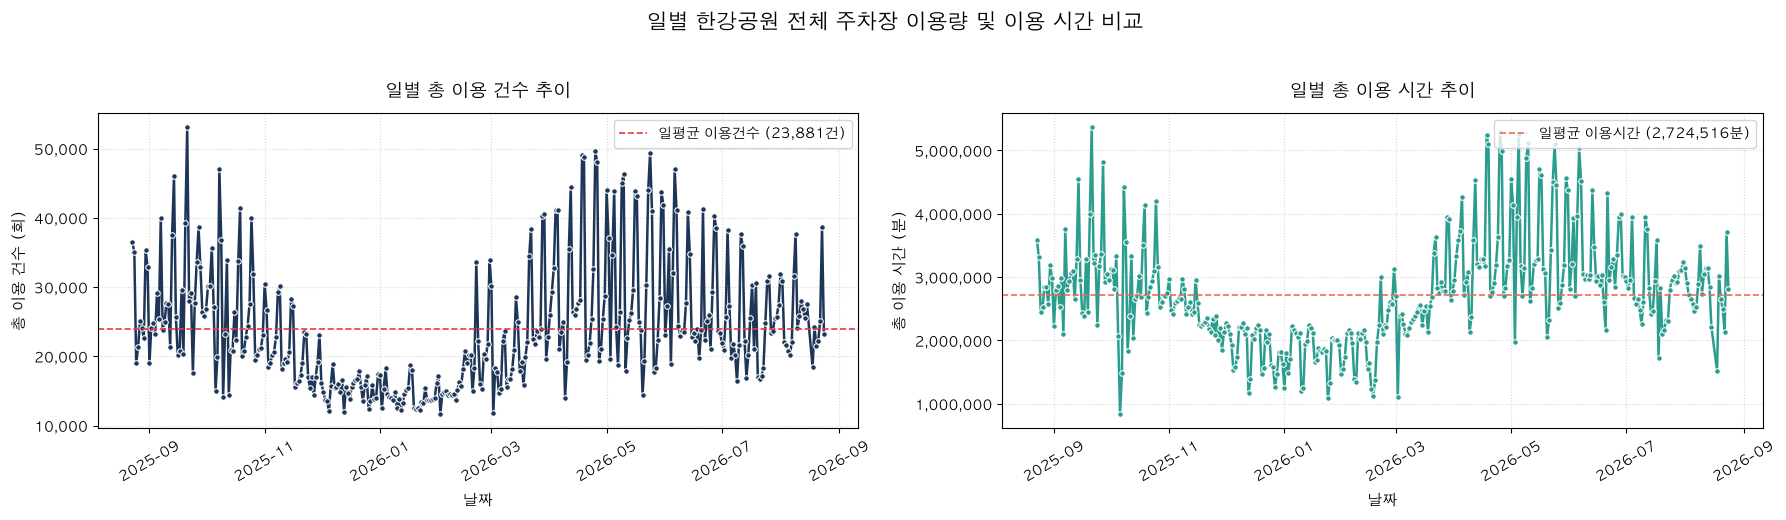

In [28]:
# 1. 날짜 변환 및 집계
date_col = 'DT'
df[date_col] = pd.to_datetime(df[date_col])

daily_summary = df.groupby(date_col).agg(
    total_cnt=('PRK_CNTOM', 'sum'),
    total_hr=('UTZTN_HR', 'sum')
).reset_index()

# 2. 1행 2열 서브플롯 생성
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

# [좌측 플롯] 총 이용 건수
sns.lineplot(
    data=daily_summary, 
    x=date_col, 
    y='total_cnt', 
    ax=ax1, 
    color='#1D3557', 
    linewidth=1.8,
    marker='o', 
    markersize=4
)
mean_cnt = daily_summary['total_cnt'].mean()
ax1.axhline(
    mean_cnt, 
    color='#E63946', 
    linestyle='--', 
    linewidth=1.2, 
    label=f'일평균 이용건수 ({int(mean_cnt):,}건)'
)
ax1.set_title('일별 총 이용 건수 추이', fontsize=13, pad=12)
ax1.set_xlabel('날짜', fontsize=11)
ax1.set_ylabel('총 이용 건수 (회)', fontsize=11)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax1.grid(True, linestyle=':', alpha=0.5)
ax1.legend(loc='upper right')
ax1.tick_params(axis='x', rotation=30)

# [우측 플롯] 총 이용 시간
sns.lineplot(
    data=daily_summary, 
    x=date_col, 
    y='total_hr', 
    ax=ax2, 
    color='#2A9D8F', 
    linewidth=1.8,
    marker='o', 
    markersize=4
)
mean_hr = daily_summary['total_hr'].mean()
ax2.axhline(
    mean_hr, 
    color='#E76F51', 
    linestyle='--', 
    linewidth=1.2, 
    label=f'일평균 이용시간 ({int(mean_hr):,}분)'
)
ax2.set_title('일별 총 이용 시간 추이', fontsize=13, pad=12)
ax2.set_xlabel('날짜', fontsize=11)
ax2.set_ylabel('총 이용 시간 (분)', fontsize=11)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax2.grid(True, linestyle=':', alpha=0.5)
ax2.legend(loc='upper right')
ax2.tick_params(axis='x', rotation=30)

plt.suptitle('일별 한강공원 전체 주차장 이용량 및 이용 시간 비교', fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

### 일별 한강공원 주차장 별 차량당 평균 이용 시간 추이

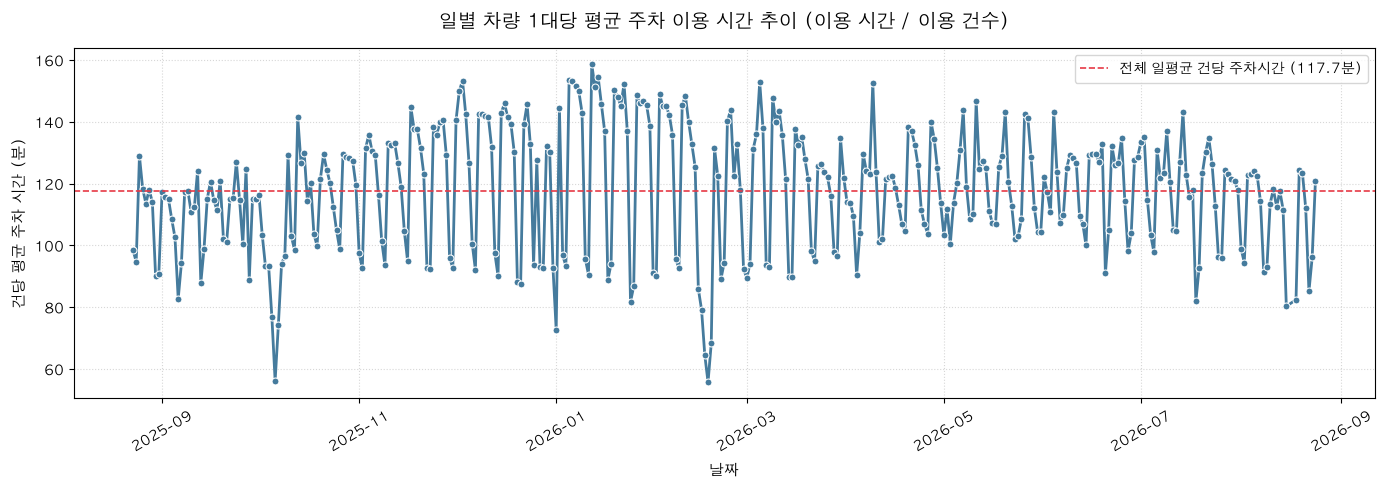

In [29]:
# 1. 날짜별 총합 집계 후 1회당 평균 이용 시간 계산
daily_summary = df.groupby(date_col).agg(
    total_cnt=('PRK_CNTOM', 'sum'),
    total_hr=('UTZTN_HR', 'sum')
).reset_index()

# 1회 이용당 평균 시간 (분 기준)
daily_summary['avg_duration_per_car'] = daily_summary['total_hr'] / daily_summary['total_cnt']

plt.figure(figsize=(14, 5))

sns.lineplot(
    data=daily_summary,
    x=date_col,
    y='avg_duration_per_car',
    color='#457B9D',
    linewidth=2,
    marker='o',
    markersize=5
)

# 전체 기간 평균선
mean_duration = daily_summary['avg_duration_per_car'].mean()
plt.axhline(
    mean_duration,
    color='#E63946',
    linestyle='--',
    linewidth=1.2,
    label=f'전체 일평균 건당 주차시간 ({mean_duration:.1f}분)'
)

plt.title('일별 차량 1대당 평균 주차 이용 시간 추이 (이용 시간 / 이용 건수)', fontsize=14, pad=15)
plt.xlabel('날짜', fontsize=11)
plt.ylabel('건당 평균 주차 시간 (분)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

* 계절적 특성:<br>
한강공원 주차장은 혹한기(겨울)를 제외한 봄·여름·가을철에 전반적으로 활발한 이용 패턴을 보입니다.

* 주간 주기성 (이용량):<br>
총 이용 건수와 총 이용 시간은 평일(5일)에 낮고 주말(2일)에 급증하는 뚜렷한 주간 주기(Weekly Periodicity)를 나타냅니다.

* 체류 시간의 역전 현상:<br>
반면, 차량 1대당 평균 체류 시간은 주말보다 평일에 더 길게 나타나는 상반된 패턴을 보입니다.

* 이용 목적 추정:
  * 평일: 인근 직장인 통근 및 업무 목적의 장기 주차(고체류·저유입) 형태
  * 주말: 순수 공원 나들이 및 여가 목적의 단기 회전 주차(저체류·대량 유입) 형태

### 요일별 이용량과 평균 이용 시간 확인
* 분석 목적: 시계열 추세선에서 관측된 "평일(통근형 장기 주차) vs 주말(여가형 대량 유입·단기 체류)" 가설을 요일별 집계를 통해 명확히 검증합니다.

* 주요 분석 지표:
  * 요일별 하루 평균 주차 이용 건수 (회)
  * 요일별 차량 1대당 평균 체류 시간 (분)

/var/folders/yd/3llw30vx5k3241gyl8_mwl_w0000gn/T/ipykernel_46141/2385118502.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/yd/3llw30vx5k3241gyl8_mwl_w0000gn/T/ipykernel_46141/2385118502.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


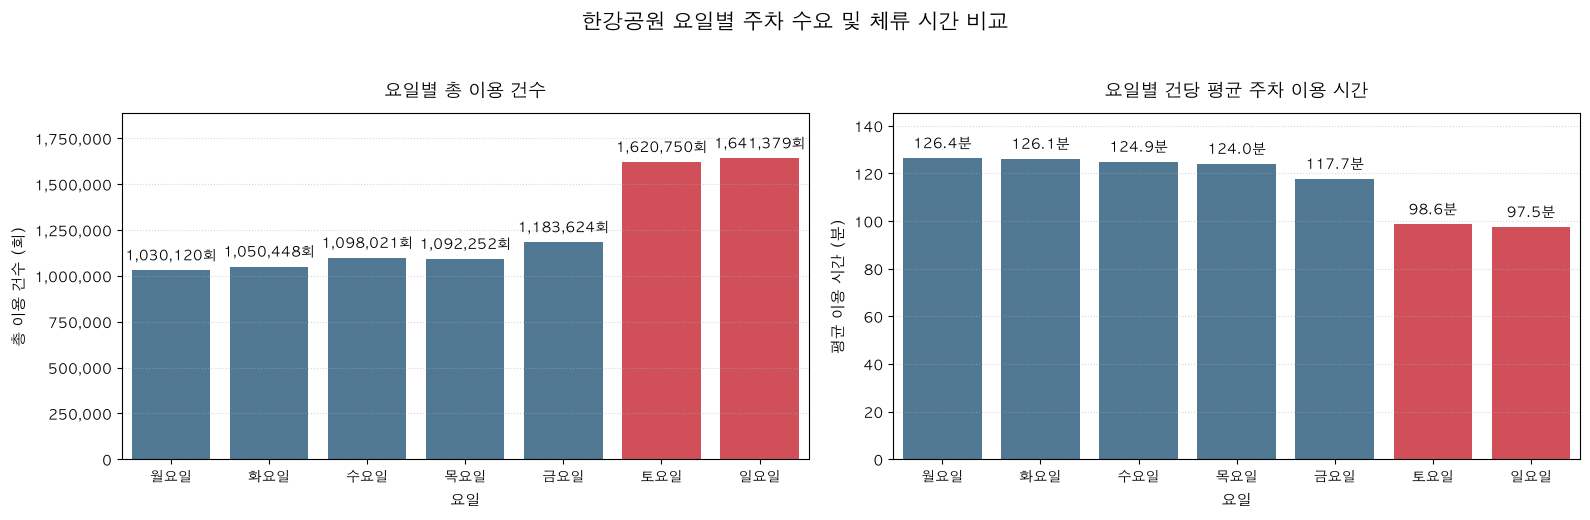

In [30]:
# 1. 요일 컬럼 생성 (월~일 순서 고정)
weekday_order = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일']
df['DAY_NAME'] = df['DT'].dt.day_name() # 영문 요일
# 한글 요일 매핑
kr_days = {'Monday': '월요일', 'Tuesday': '화요일', 'Wednesday': '수요일', 
           'Thursday': '목요일', 'Friday': '금요일', 'Saturday': '토요일', 'Sunday': '일요일'}
df['DAY_OF_WEEK'] = df['DAY_NAME'].map(kr_days)

# 2. 요일별 집계
weekday_summary = df.groupby('DAY_OF_WEEK').agg(
    total_cnt=('PRK_CNTOM', 'sum'),
    total_hr=('UTZTN_HR', 'sum')
).reindex(weekday_order).reset_index()

# 건당 평균 주차 시간 (분)
weekday_summary['avg_duration_per_car'] = weekday_summary['total_hr'] / weekday_summary['total_cnt']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# 주말(토/일) 강조 색상 팔레트 설정
colors = ['#457B9D' if day not in ['토요일', '일요일'] else '#E63946' for day in weekday_order]

# [좌측 플롯] 요일별 총 이용 건수
sns.barplot(
    data=weekday_summary,
    x='DAY_OF_WEEK',
    y='total_cnt',
    palette=colors,
    ax=ax1
)
for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        ax1.annotate(
            f'{int(height):,}회',
            xy=(p.get_x() + p.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=10
        )
ax1.set_title('요일별 총 이용 건수', fontsize=13, pad=12)
ax1.set_xlabel('요일', fontsize=11)
ax1.set_ylabel('총 이용 건수 (회)', fontsize=11)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax1.set_ylim(0, weekday_summary['total_cnt'].max() * 1.15)
ax1.grid(axis='y', linestyle=':', alpha=0.5)

# [우측 플롯] 요일별 건당 평균 이용 시간
sns.barplot(
    data=weekday_summary,
    x='DAY_OF_WEEK',
    y='avg_duration_per_car',
    palette=colors,
    ax=ax2
)
for p in ax2.patches:
    height = p.get_height()
    if height > 0:
        ax2.annotate(
            f'{height:.1f}분',
            xy=(p.get_x() + p.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=10
        )
ax2.set_title('요일별 건당 평균 주차 이용 시간', fontsize=13, pad=12)
ax2.set_xlabel('요일', fontsize=11)
ax2.set_ylabel('평균 이용 시간 (분)', fontsize=11)
ax2.set_ylim(0, weekday_summary['avg_duration_per_car'].max() * 1.15)
ax2.grid(axis='y', linestyle=':', alpha=0.5)

plt.suptitle('한강공원 요일별 주차 수요 및 체류 시간 비교', fontsize=15, y=1.03)
plt.tight_layout()
plt.show()


* 요일별 데이터 집계 결과, 주말 하루 평균 주차 이용 건수는 평일 대비 약 1.5배에 달하며 수요가 급증했습니다.

* 반면, 차량 1대당 평균 체류 시간은 평일 대비 약 80% 수준으로 단축되는 반전 패턴을 명확히 확인하였습니다.

* 이를 통해 '평일은 통근·업무 목적의 소규모 장기 주차', '주말은 여가·나들이 목적의 대량 단기 회전 주차'로 설정했던 가설을 정량적으로 입증할 수 있었습니다.

### 지구별 총 이용건수, 총 이용 시간, 평균 체류시간 확인

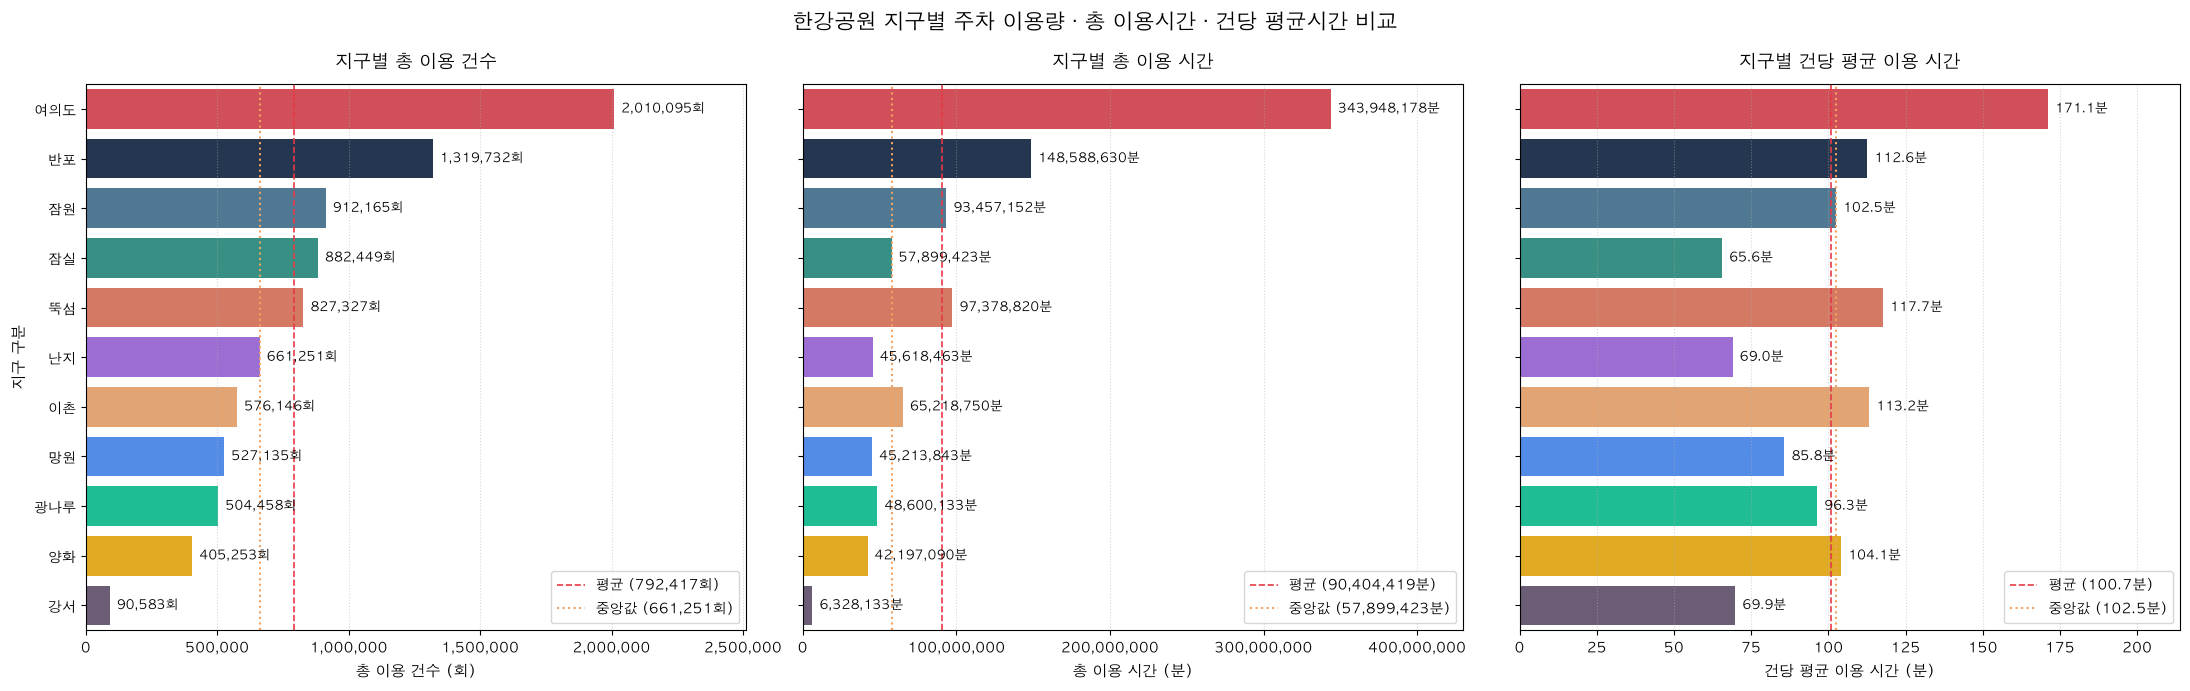

In [31]:
# 1. 데이터 집계 및 계산
district_summary = df.groupby('DSTRCT_TYPE').agg(
    total_cnt=('PRK_CNTOM', 'sum'),
    total_hr=('UTZTN_HR', 'sum')
).reset_index()

district_summary['avg_duration'] = district_summary['total_hr'] / district_summary['total_cnt']
district_summary = district_summary.sort_values(by='total_cnt', ascending=False).reset_index(drop=True)

# 2. 1행 3열 서브플롯 생성
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7), sharey=True)
palette_colors = use_palette(district_summary['DSTRCT_TYPE'].nunique())

# -------------------------------------------------------------
# [1. 지구별 총 이용 건수]
# -------------------------------------------------------------
sns.barplot(
    data=district_summary,
    x='total_cnt',
    y='DSTRCT_TYPE',
    hue='DSTRCT_TYPE',
    palette=palette_colors,
    legend=False,
    ax=ax1
)
for p in ax1.patches:
    w = p.get_width()
    if w > 0:
        ax1.annotate(f'{int(w):,}회', xy=(w, p.get_y() + p.get_height() / 2),
                     xytext=(5, 0), textcoords="offset points", ha='left', va='center', fontsize=9)

mean_cnt = district_summary['total_cnt'].mean()
median_cnt = district_summary['total_cnt'].median()
ax1.axvline(mean_cnt, color='#E63946', linestyle='--', linewidth=1.2, label=f'평균 ({int(mean_cnt):,}회)')
ax1.axvline(median_cnt, color='#F4A261', linestyle=':', linewidth=1.5, label=f'중앙값 ({int(median_cnt):,}회)')

ax1.set_title('지구별 총 이용 건수', fontsize=13, pad=12)
ax1.set_xlabel('총 이용 건수 (회)', fontsize=11)
ax1.set_ylabel('지구 구분', fontsize=11)
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax1.set_xlim(0, district_summary['total_cnt'].max() * 1.25)
ax1.grid(axis='x', linestyle=':', alpha=0.5)
ax1.legend(loc='lower right', frameon=True)

# -------------------------------------------------------------
# [2. 지구별 총 이용 시간]
# -------------------------------------------------------------
sns.barplot(
    data=district_summary,
    x='total_hr',
    y='DSTRCT_TYPE',
    hue='DSTRCT_TYPE',
    palette=palette_colors,
    legend=False,
    ax=ax2
)
for p in ax2.patches:
    w = p.get_width()
    if w > 0:
        ax2.annotate(f'{int(w):,}분', xy=(w, p.get_y() + p.get_height() / 2),
                     xytext=(5, 0), textcoords="offset points", ha='left', va='center', fontsize=9)

mean_hr = district_summary['total_hr'].mean()
median_hr = district_summary['total_hr'].median()
ax2.axvline(mean_hr, color='#E63946', linestyle='--', linewidth=1.2, label=f'평균 ({int(mean_hr):,}분)')
ax2.axvline(median_hr, color='#F4A261', linestyle=':', linewidth=1.5, label=f'중앙값 ({int(median_hr):,}분)')

ax2.xaxis.set_major_locator(ticker.MultipleLocator(100000000))
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1e8:.1f}억' if x > 0 else '0'))

ax2.set_title('지구별 총 이용 시간', fontsize=13, pad=12)
ax2.set_xlabel('총 이용 시간 (분)', fontsize=11)
ax2.set_ylabel('')
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax2.set_xlim(0, district_summary['total_hr'].max() * 1.25)
ax2.grid(axis='x', linestyle=':', alpha=0.5)
ax2.legend(loc='lower right', frameon=True)

# -------------------------------------------------------------
# [3. 지구별 건당 평균 이용 시간]
# -------------------------------------------------------------
sns.barplot(
    data=district_summary,
    x='avg_duration',
    y='DSTRCT_TYPE',
    hue='DSTRCT_TYPE',
    palette=palette_colors,
    legend=False,
    ax=ax3
)
for p in ax3.patches:
    w = p.get_width()
    if w > 0:
        ax3.annotate(f'{w:.1f}분', xy=(w, p.get_y() + p.get_height() / 2),
                     xytext=(5, 0), textcoords="offset points", ha='left', va='center', fontsize=9)

mean_dur = district_summary['avg_duration'].mean()
median_dur = district_summary['avg_duration'].median()
ax3.axvline(mean_dur, color='#E63946', linestyle='--', linewidth=1.2, label=f'평균 ({mean_dur:.1f}분)')
ax3.axvline(median_dur, color='#F4A261', linestyle=':', linewidth=1.5, label=f'중앙값 ({median_dur:.1f}분)')

ax3.set_title('지구별 건당 평균 이용 시간', fontsize=13, pad=12)
ax3.set_xlabel('건당 평균 이용 시간 (분)', fontsize=11)
ax3.set_ylabel('')
ax3.set_xlim(0, district_summary['avg_duration'].max() * 1.25)
ax3.grid(axis='x', linestyle=':', alpha=0.5)
ax3.legend(loc='lower right', frameon=True)

plt.suptitle('한강공원 지구별 주차 이용량 · 총 이용시간 · 건당 평균시간 비교', fontsize=15, y=0.98)
plt.tight_layout()
plt.show()

1. 여의도 지구의 압도적 집중 (수요 규모 및 체류 시간 1위)
  * 수요 규모 압도:<br>
  총 이용 건수(201만 회)와 총 체류 시간(약 3.4억 분) 모두 2위권 지구 대비 약 2배 격차를 보이며 전체 통계를 견인하고 있습니다.
  * 낮은 회전율과 만차 구조:<br>
  건당 평균 이용 시간이 171.1분(약 2시간 50분)으로 전 지구 중 최장입니다. 최다 차량 유입과 장시간 체류가 결합되어 주차 회전율이 매우 낮고 상시 혼잡도가 극심한 취약 구조를 띱니다.

2. 지구별 이용 특성 세분화 (장기 체류형 vs 단기 회전형)
* 장기 체류형 지구 (건당 평균 100분 초과)
  * 해당 지구:<br>
  여의도(171.1분), 뚝섬(117.7분), 이촌(113.2분), 반포(112.6분), 양화(104.1분)
  * 특성 및 과제:<br>
  피크닉, 텐트, 돗자리 이용 등 머무름 중심의 레저 활동 및 인근 업무 배후 수요가 혼재되어 주차 공간 확보 및 장기 주차 관리가 핵심 과제입니다.

* 단기 회전형 지구 (건당 평균 100분 미만)
  * 해당 지구: <br>잠실(65.6분), 난지(69.0분), 강서(69.9분), 망원(85.8분)
  * 특성 및 과제:<br>
  특히 잠실은 총 이용 건수(88만 회)가 상위권임에도 체류 시간은 65.6분으로 매우 짧아, 운동·산책·특정 시설 이용 등 단기 목적성 방문 위주의 빠른 회전율을 보입니다.

3. 데이터 해석상 제약 사항<br>
⚠️ 망원 4주차장 및 이촌 4주차장의 일별 이용 데이터 미집계로 인해, 망원·이촌 지구의 전체 총량은 실제보다 다소 과소 집계되었을 가능성이 있습니다.

### 한강공원 별 주차 수용 및 평균 체류시간 확인

In [32]:
# 1. 요일 정의 및 순서 정렬
weekday_order = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일']
kr_days = {'Monday': '월요일', 'Tuesday': '화요일', 'Wednesday': '수요일', 
           'Thursday': '목요일', 'Friday': '금요일', 'Saturday': '토요일', 'Sunday': '일요일'}

df['DAY_OF_WEEK'] = df['DT'].dt.day_name().map(kr_days)

# 2. 지구 x 요일 집계
dstrct_day_df = df.groupby(['DSTRCT_TYPE', 'DAY_OF_WEEK']).agg(
    total_cnt=('PRK_CNTOM', 'sum'),
    total_hr=('UTZTN_HR', 'sum')
).reset_index()

# 건당 평균 이용 시간 (분)
dstrct_day_df['avg_duration'] = dstrct_day_df['total_hr'] / dstrct_day_df['total_cnt']

# 지구 정렬 순서 (전체 이용량 많은 순)
district_order = df.groupby('DSTRCT_TYPE')['PRK_CNTOM'].sum().sort_values(ascending=False).index

# 피벗 테이블 생성 (Y축: 지구, X축: 요일)
cnt_pivot = dstrct_day_df.pivot(index='DSTRCT_TYPE', columns='DAY_OF_WEEK', values='total_cnt').reindex(index=district_order, columns=weekday_order)
dur_pivot = dstrct_day_df.pivot(index='DSTRCT_TYPE', columns='DAY_OF_WEEK', values='avg_duration').reindex(index=district_order, columns=weekday_order)

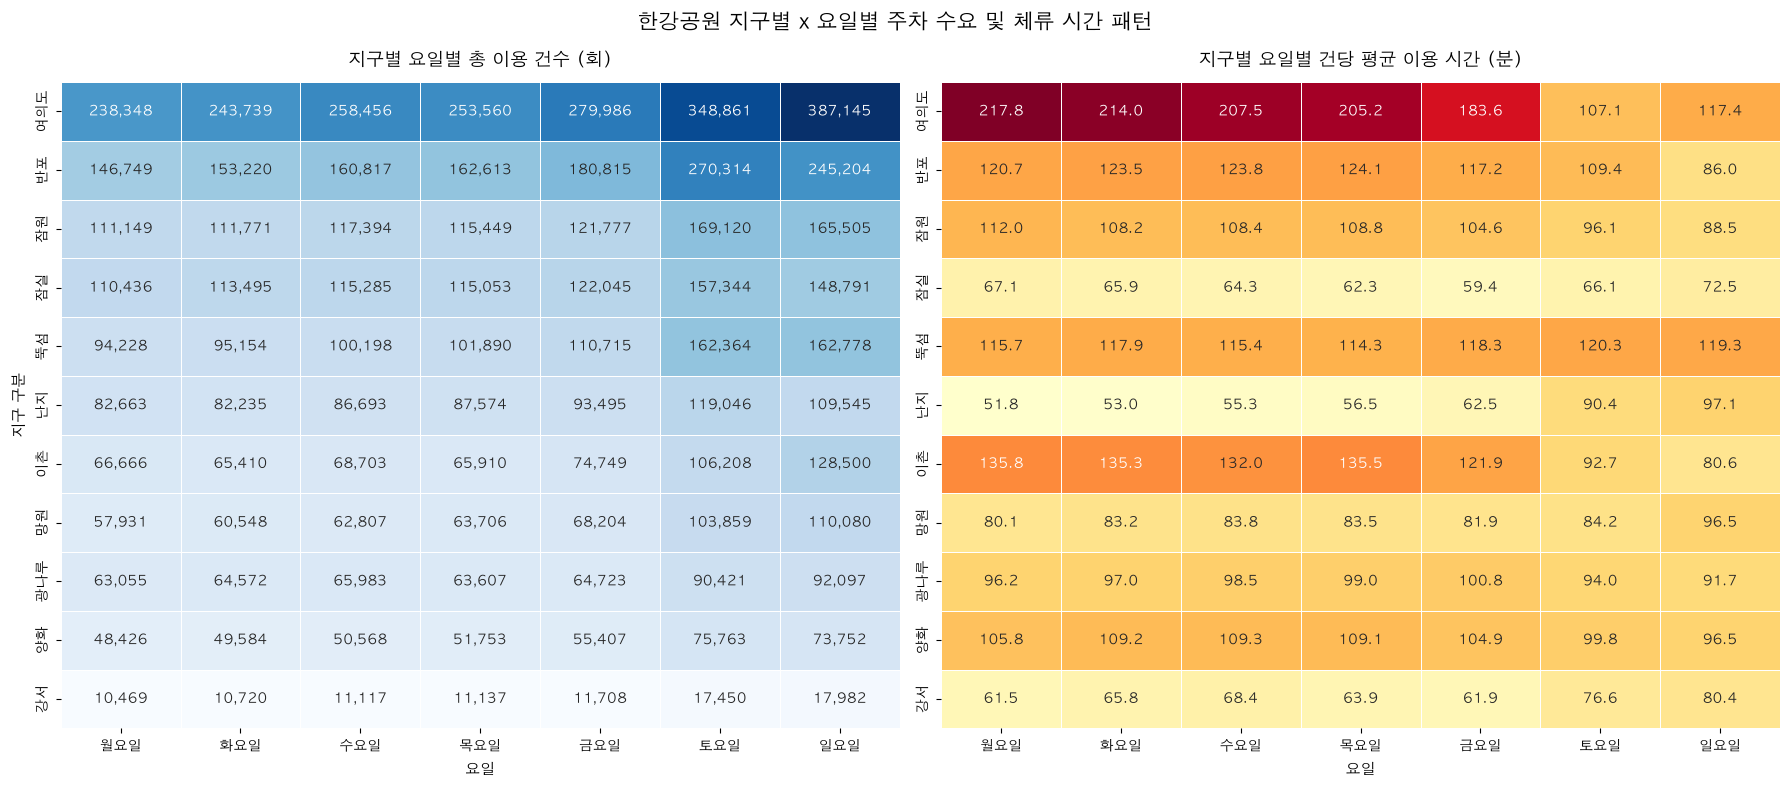

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# [좌측] 지구별 요일별 총 이용 건수 히트맵
sns.heatmap(
    cnt_pivot,
    annot=True,
    fmt=',.0f',
    cmap='Blues',
    cbar=False,
    linewidths=0.5,
    ax=ax1
)
ax1.set_title('지구별 요일별 총 이용 건수 (회)', fontsize=13, pad=12)
ax1.set_xlabel('요일', fontsize=11)
ax1.set_ylabel('지구 구분', fontsize=11)

# [우측] 지구별 요일별 건당 평균 이용 시간 히트맵
sns.heatmap(
    dur_pivot,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    cbar=False,
    linewidths=0.5,
    ax=ax2
)
ax2.set_title('지구별 요일별 건당 평균 이용 시간 (분)', fontsize=13, pad=12)
ax2.set_xlabel('요일', fontsize=11)
ax2.set_ylabel('')

plt.suptitle('한강공원 지구별 x 요일별 주차 수요 및 체류 시간 패턴', fontsize=15, y=0.98)
plt.tight_layout()
plt.show()

1. 이용 건수(좌측): 전 지구적 주말 쏠림 현상
* 주말 폭증: <br>
모든 지구에서 평일 대비 토·일요일 이용 건수가 40% ~ 70% 이상 급증합니다.

* 여의도·반포의 압도적 볼륨: <br>
여의도는 평일(23~27만) 대비 일요일(38.7만), 반포는 평일(14~18만) 대비 토요일(27.0만)에 폭발적인 유입을 기록하며 전체 트래픽을 주도합니다.
* 금요일의 반등: <br>
월~목 대비 금요일부터 전 지구적으로 유입량이 완만하게 상승하기 시작합니다.

2. 건당 체류 시간(우측): 평일 vs 주말의 상반된 반전 패턴 (핵심)
* 업무/비즈니스 배후 지구의 역전 현상 (평일 체류시간 > 주말 체류시간)
  * 여의도: <br>
  평일 체류 시간은 205~217분(약 3시간 반)에 달하지만, 주말에는 오히려 107~117분(약 1시간 50분)으로 절반 가까이 급감합니다.
  * 반포·이촌·잠원: <br>
  평일 체류 시간(110~135분)이 주말(80~109분)보다 더 깁니다.

  * 원인: 평일에는 인근 직장인, 상가, 주변 시설 관련 장기 주차 차량이 많으나, 주말에는 일반 나들이객의 유입이 폭증하고 만차로 인해 주차 회전율이 강제 상승하기 때문입니다.

* 순수 피크닉/레저 지구의 정석 패턴 (평일 체류시간 < 주말 체류시간)

  * 난지:<br>
  평일(51~62분) 대비 주말(90~97분)에 체류 시간이 약 70% 증가합니다. (캠핑·페스티벌·가족 나들이 특성)

  * 강서·망원:<br>
  주말에 체류 시간이 늘어나는 순수 레저형 특성을 보입니다.

* 상시 장기 체류 지구 (평일·주말 모두 고체류)

  * 뚝섬:<br>
  월~일 전 요일에 걸쳐 115~120분 수준을 균일하게 유지하며, 요일에 상관없이 이용이 이루어지는 복합 특성을 나타냅니다.

3. 종합 요약 및 관리 시사점

* 여의도·반포·이촌:<br>
평일은 장기 주차(업무 배후 수요) 관리, 주말은 단시간 대규모 유입(회전율 및 만차 대응) 관리로 이원화된 정책이 필요합니다.

* 난지·망원·강서:<br>주말 가족 단위 장기 체류객을 위한 주차 인프라 및 체류형 콘텐츠 관리가 적합합니다.

# ⚙️ 군집 분석

## 주차장별 군집 분석

### 군집 분석용 테이블 생성

In [34]:
# 1. 그룹화 기준 키 정의 (지구 구분 + 주차장명)
group_keys = ['DSTRCT_TYPE', 'PKLT_NM']

# 2. 평일(is_weekend=0) / 주말(is_weekend=1) 이용 실적 집계
period_agg = df.groupby(group_keys + ['is_weekend']).agg(
    daily_avg_cnt=('PRK_CNTOM', 'mean'),  # 일평균 이용 건수
    total_cnt=('PRK_CNTOM', 'sum'),        # 총 이용 건수
    total_hr=('UTZTN_HR', 'sum')           # 총 이용 시간(분)
).unstack('is_weekend')

# 컬럼 멀티인덱스 정리 (예: daily_avg_cnt_0, daily_avg_cnt_1)
period_agg.columns = [f'{col}_{val}' for col, val in period_agg.columns]
period_agg = period_agg.reset_index()

# 3. 주차장 메타데이터 및 전체 수요 집계
lot_meta = df.groupby(group_keys).agg(
    total_demand=('PRK_CNTOM', 'sum'),      # [피처 3] 총 수요 규모
    daily_mean_cnt=('PRK_CNTOM', 'mean'),   # 전체 일평균 이용 건수
    capacity=('PRK_CNT', 'first'),          # 주차면수
    lat=('PSTN_INFO_LAT', 'first'),         # 위도
    lot=('PSTN_INFO_LOT', 'first')          # 경도
).reset_index()

# 4. 테이블 결합 및 4대 핵심 피처 산출
lot_cluster_df = pd.merge(lot_meta, period_agg, on=group_keys)

# [피처 1] 평일 / 주말 하루 평균 이용 횟수 (대/일)
lot_cluster_df['weekday_cnt'] = lot_cluster_df['daily_avg_cnt_0']
lot_cluster_df['weekend_cnt'] = lot_cluster_df['daily_avg_cnt_1']

# [피처 2] 평일 / 주말 차량 1대당 평균 체류시간 (분/대)
lot_cluster_df['weekday_duration'] = lot_cluster_df['total_hr_0'] / (lot_cluster_df['total_cnt_0'] + 1e-5)
lot_cluster_df['weekend_duration'] = lot_cluster_df['total_hr_1'] / (lot_cluster_df['total_cnt_1'] + 1e-5)

# [피처 4] 주차면 1면당 일평균 회전율 (회/면·일)
lot_cluster_df['turnover_rate'] = lot_cluster_df['daily_mean_cnt'] / lot_cluster_df['capacity']

# 군집 분석 투입용 피처 리스트
feature_cols = [
    'weekday_cnt', 
    'weekend_cnt', 
    'weekday_duration', 
    'weekend_duration', 
    'total_demand', 
    'turnover_rate'
]

# 5. 결과 확인
display(lot_cluster_df[['DSTRCT_TYPE', 'PKLT_NM', 'capacity'] + feature_cols].head())
print(f"총 {len(lot_cluster_df)}개 주차장 집계 완료 (Shape: {lot_cluster_df.shape})")

,DSTRCT_TYPE,PKLT_NM,capacity,weekday_cnt,weekend_cnt,weekday_duration,weekend_duration,total_demand,turnover_rate
0,강서,강서1주차장,99,212.119231,337.447619,64.298562,78.516680,90583,2.506794
1,광나루,"광나루1,2주차장",160,551.938462,951.790476,96.309274,96.694260,243442,4.168527
2,광나루,광나루3주차장,183,394.615385,652.009524,93.580838,89.813412,171061,2.560985
3,광나루,광나루4주차장,46,291.676923,134.466667,108.563294,80.233728,89955,5.357653
4,난지,"난지1,2,3,4주차장",618,1664.076923,2177.057143,55.986662,93.596310,661251,2.931467


총 28개 주차장 집계 완료 (Shape: (28, 18))


### 최적 K값 확인

=== 표준화된 피처 데이터 (상위 5개 주차장) ===


,weekday_cnt,weekend_cnt,weekday_duration,weekend_duration,total_demand,turnover_rate
PKLT_NM,,,,,,
강서1주차장,-0.871159,-0.853727,-0.915206,-0.770145,-0.868934,-0.732554
"광나루1,2주차장",-0.320004,-0.174453,-0.438986,0.008632,-0.267167,-0.153532
광나루3주차장,-0.575167,-0.505919,-0.479577,-0.286162,-0.552112,-0.713671
광나루4주차장,-0.742124,-1.078162,-0.256684,-0.696582,-0.871406,0.260812
"난지1,2,3,4주차장",1.483780,1.180315,-1.038862,-0.124092,1.377640,-0.584579



=== K값별 평가 지표 ===


,K (군집 수),Inertia (군집 내 분산 합),Silhouette Score (실루엣 점수)
0,2,101.9607,0.4178
1,3,75.6898,0.3436
2,4,64.1187,0.3015
3,5,52.2023,0.2759
4,6,42.3538,0.2808


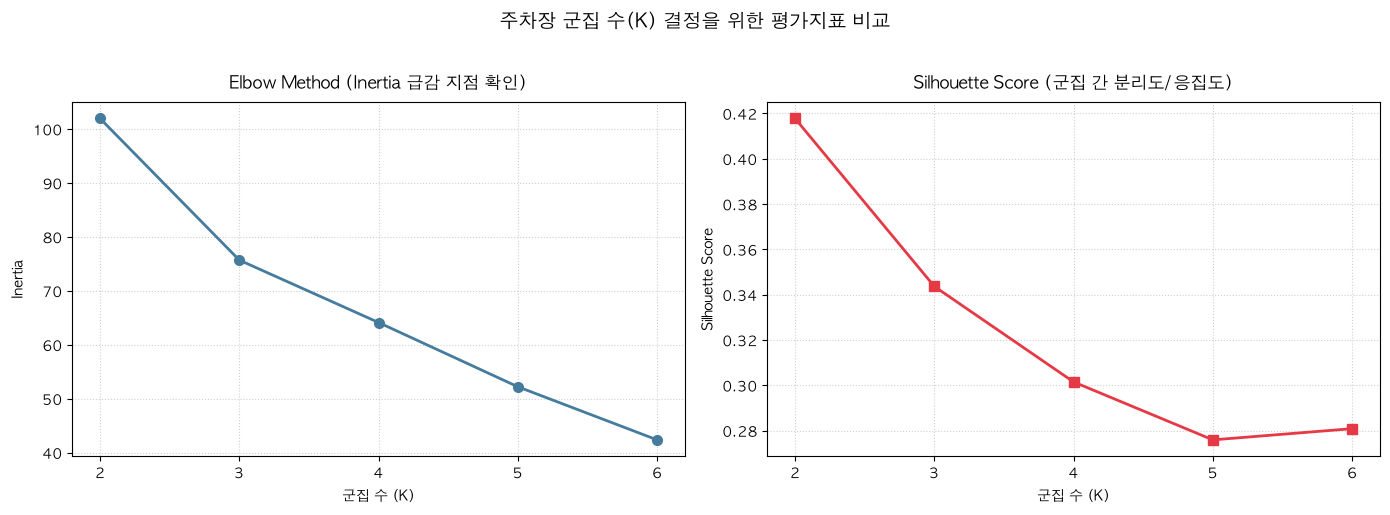

In [35]:
# 1. 군집화 대상 피처 선택 및 표준화
X = lot_cluster_df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 표준화 결과 확인용 (DataFrame)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols, index=lot_cluster_df['PKLT_NM'])
print("=== 표준화된 피처 데이터 (상위 5개 주차장) ===")
display(X_scaled_df.head())

# 2. 군집 수(K=2 ~ 6)에 따른 Inertia 및 Silhouette Score 계산
k_range = range(2, 7)
inertia_list = []
silhouette_list = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    inertia_list.append(kmeans.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, cluster_labels))

# 3. K 탐색 결과 요약 테이블 출력
k_eval_df = pd.DataFrame({
    'K (군집 수)': list(k_range),
    'Inertia (군집 내 분산 합)': inertia_list,
    'Silhouette Score (실루엣 점수)': silhouette_list
})
print("\n=== K값별 평가 지표 ===")
display(k_eval_df.round(4))

# 4. 엘보우 차트 및 실루엣 점수 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# (1) Elbow Method (Inertia)
ax1.plot(k_range, inertia_list, marker='o', color='#457B9D', linewidth=2, markersize=7)
ax1.set_title('Elbow Method (Inertia 급감 지점 확인)', fontsize=12, pad=10)
ax1.set_xlabel('군집 수 (K)', fontsize=10)
ax1.set_ylabel('Inertia', fontsize=10)
ax1.set_xticks(k_range)
ax1.grid(True, linestyle=':', alpha=0.6)

# (2) Silhouette Score
ax2.plot(k_range, silhouette_list, marker='s', color='#E63946', linewidth=2, markersize=7)
ax2.set_title('Silhouette Score (군집 간 분리도/응집도)', fontsize=12, pad=10)
ax2.set_xlabel('군집 수 (K)', fontsize=10)
ax2.set_ylabel('Silhouette Score', fontsize=10)
ax2.set_xticks(k_range)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('주차장 군집 수(K) 결정을 위한 평가지표 비교', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 군집화 진행 (K=3)

In [36]:
# 1. K=3 K-Means 모델 학습 및 군집 할당
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
lot_cluster_df['cluster'] = kmeans.fit_predict(X_scaled)

# 2. 군집별 주요 피처 평균 요약표 산출
cluster_profile = lot_cluster_df.groupby('cluster')[feature_cols + ['capacity']].mean()

# 가독성을 위한 컬럼명 한글화 및 반올림
profile_summary = cluster_profile.rename(columns={
    'weekday_cnt': '평일 이용건수(회/일)',
    'weekend_cnt': '주말 이용건수(회/일)',
    'weekday_duration': '평일 체류시간(분)',
    'weekend_duration': '주말 체류시간(분)',
    'total_demand': '총 수요량(건)',
    'turnover_rate': '면당 회전율(회/면·일)',
    'capacity': '평균 주차면수(면)'
}).round(2)

# 주차장 개수 추가
profile_summary.insert(0, '주차장 수(개소)', lot_cluster_df['cluster'].value_counts().sort_index())

print("=== [군집별 핵심 특성 평균 프로파일] ===")
display(profile_summary)

# 3. 군집별 주차장 배정 현황 출력
print("\n=== [군집별 주차장 목록 및 소속 지구] ===")
for c in sorted(lot_cluster_df['cluster'].unique()):
    sub_df = lot_cluster_df[lot_cluster_df['cluster'] == c]
    lots_with_district = [f"{row['PKLT_NM']}({row['DSTRCT_TYPE']})" for _, row in sub_df.iterrows()]
    print(f"\n▶ 군집 {c} (총 {len(sub_df)}개소):")
    print("  " + ", ".join(lots_with_district))

=== [군집별 핵심 특성 평균 프로파일] ===


,주차장 수(개소),평일 이용건수(회/일),주말 이용건수(회/일),평일 체류시간(분),주말 체류시간(분),총 수요량(건),면당 회전율(회/면·일),평균 주차면수(면)
cluster,,,,,,,,
0,6,1762.21,2475.32,108.58,86.23,718083.50,6.63,392.33
1,5,562.24,827.32,243.33,124.70,233049.60,2.19,318.60
2,17,446.72,710.55,97.34,91.82,190755.59,4.61,135.35



=== [군집별 주차장 목록 및 소속 지구] ===

▶ 군집 0 (총 6개소):
  난지1,2,3,4주차장(난지), 반포2,3주차장(반포), 여의도1주차장(여의도), 여의도2주차장(여의도), 잠실1주차장(잠실), 잠원2-6주차장(잠원)

▶ 군집 1 (총 5개소):
  뚝섬2주차장(뚝섬), 여의도3주차장(여의도), 여의도4주차장(여의도), 여의도5주차장(여의도), 이촌2주차장(이촌)

▶ 군집 2 (총 17개소):
  강서1주차장(강서), 광나루1,2주차장(광나루), 광나루3주차장(광나루), 광나루4주차장(광나루), 뚝섬1주차장(뚝섬), 뚝섬3주차장(뚝섬), 뚝섬4주차장(뚝섬), 망원1주차장(망원), 망원2주차장(망원), 반포1주차장(반포), 양화1주차장(양화), 양화2주차장(양화), 양화3주차장(양화), 이촌1주차장(이촌), 이촌3주차장(이촌), 잠실2,3주차장(잠실), 잠원1주차장(잠원)


군집별 세부 해석
1. 군집 0: "대규모·초고회전형" (6개소)
  * 특징: <br>
  총 수요량(약 71.8만 건)과 평일(1,762회)/주말(2,475회) 이용량이 타 군집 대비 압도적으로 높습니다.
  * 이용 행태: <br>
  평균 392면의 대형 주차장이지만, 면당 일평균 회전율이 6.63회에 달할 정도로 차량 유출입이 매우 빈번합니다.
  * 체류 패턴: <br>
  평일 108분, 주말 86분으로 체류 시간이 비교적 짧아 많은 차량이 빠르게 회전하며 공원을 이용하는 핵심 거점형 주차장입니다. (예: 여의도 메인, 뚝섬 대형 구역 등)

2. 군집 1: "오피스 배후·초장기 통근 체류형" (5개소)
  * 특징: <br>
  평일 체류시간이 243.33분(약 4시간 이상)으로 전 군집 중 압도적으로 깁니다.
  * 이용 행태: <br>
  318면 규모를 갖췄음에도 면당 회전율은 2.19회로 가장 낮습니다. 차가 한 번 들어오면 반나절 가까이 머무르기 때문에 회전이 거의 일어나지 않습니다.
  * 추정 원인: <br>
  주말(124.7분) 대비 평일 체류시간이 2배 가까이 폭증하는 것으로 보아, 인근 업무지구 출퇴근 차량 및 종일 주차 수요가 집중되는 구역입니다. (예: 여의도 업무지구 인접 주차장 등)

3. 군집 2: "중소규모 근린·생활 레저형" (17개소)
  * 특징: <br>
  28개 중 17개소(약 60%)가 속한 가장 일반적인 한강공원 주차장 형태입니다.
  * 이용 행태: <br>
  평균 면수가 135.4면으로 아담하며, 평일/주말 체류시간이 약 90~97분(1시간 반 내외)으로 균일합니다.
  * 체류 패턴: <br>
  산책, 가벼운 운동, 피크닉 등 근린 생활권 주민들의 일상적 방문 위주로 안정적인 회전율(4.61회)을 보입니다.

---

군집별 주요 운영 과제 및 비가격적 개선 전략
* 공공시설 특성상 단순 요금 인상 등 가격적 진입 장벽을 설정하기 어려우므로, 데이터 기반의 현장 운영 최적화와 인프라 개선 중심의 대책을 제시합니다.

1. 군집 0: "대규모·초고회전형" (6개소)
* 출입구 병목 해소를 위한 고속 출차 인프라 구축
  * 일평균 수천 대의 차량이 드나드는 초고회전 특성상 정산 대기열이 인근 간선도로 정체로 이어질 위험이 큽니다.
  * 하이패스 자동 결제 전용 차로 도입, 모바일 사전 결제 QR 확대, 무정차 자동 정산 시스템 구축을 우선 추진하여 입출차 회전 속도를 극대화합니다.

* 실시간 주차 정보 연동을 통한 사전 우회 유도
  * 만차와 회차가 실시간으로 반복되므로, 주요 접근로 VMS 전광판 및 민간 모빌리티 플랫폼(Tmap, 카카오내비 등)에 실시간 잔여 면수 데이터를 실시간 개방합니다.
  * 만차 시 인근 대체 주차장 안내를 화면에 노출하여 진입로 불필요한 꼬리물기와 대기 행렬을 차단합니다.

* 주말 피크타임 현장 안전 관리 인력 탄력 배치
  * 주말 이용량이 2,000건 이상으로 폭증하는 특성을 고려해, 혼잡 시간대 진입로와 주차장 내부에 모범운전자 및 현장 안내 요원을 집중 투입합니다.
  * 구역 내 보행자-차량 간 동선을 분리하고 접촉 사고를 사전에 예방합니다.

2. 군집 1: "오피스 배후·초장기 통근 체류형" (5개소)
* 비공원 목적 장기 박차 관리 기준 정립
  * 평일 평균 체류시간이 4시간 이상으로 극단적인 양상을 보이므로, 인근 업무지구 통근 차량의 상습 종일 주차를 억제할 관리 기준을 마련합니다.
  * 평일 월정기권 발급 규모를 축소하거나 발급 요건을 공원 정기 이용 증빙자 중심으로 엄격히 제한하여 주차장 본래의 공공성을 회복합니다.

* 목적별 주차 구획 분리를 통한 공원 이용객 공간 확보
  * 낮은 회전율로 인해 정작 평일 낮 시간대 순수 공원 방문객이 만차로 진입하지 못하는 문제를 해소합니다.
  * 체육·문화 시설 이용자 및 단기 방문객 전용 '단기 주차 구획'을 별도로 지정하고, 평일과 주말의 수요 패턴 차이에 맞춰 공간 운영 방식을 탄력적으로 전환합니다.

3. 군집 2: "중소규모 근린·생활 레저형" (17개소)
* 완전 무인화 관제 시스템을 통한 운영 비용 절감
  * 평균 면수가 작고 평일과 주말의 수요 및 체류시간(약 1.5시간)이 매우 균일하게 유지되는 안정적 형태입니다.
  * 17개소 전체에 무인 사전 정산기 및 원격 중앙 통합 관제 시스템을 안착시켜 현장 상주 인건비 등 행정 관리 비용을 최소화합니다.

* 생활 밀착형 편의 인프라 및 친환경 편의시설 보강
  * 인근 주민들의 일상적 산책 및 휴식 방문이 주를 이루는 만큼, 완속 전기차 충전 구역 확충, 보행 약자(장애인·임산부·어르신) 배려 구획 정비 등 시민 편의 중심의 기본 환경 관리에 집중합니다.
 

### 군집별 위치 시각화

In [37]:
# 1. 군집별 색상 및 페르소나 명칭 정의
cluster_meta = {
    0: {'color': '#E63946', 'name': '군집 0: 대규모·초고회전형'}, # 빨강
    1: {'color': '#1D3557', 'name': '군집 1: 직장인 통근·초장기 체류형'}, # 남색
    2: {'color': '#2A9D8F', 'name': '군집 2: 중소규모 근린·생활 밀착형'}  # 청록
}

# 2. 한강 중심부 좌표로 기본 지도 생성
seoul_hangang_center = [37.5283, 126.985]
m = folium.Map(
    location=seoul_hangang_center, 
    zoom_start=12, 
    tiles='CartoDB positron',  # 주차장 마커가 잘 돋보이는 밝은 배경
    scrollWheelZoom=False  # 마우스 스크롤 줌 비활성화
)

# 3. 28개 주차장 마커 렌더링
for _, row in lot_cluster_df.iterrows():
    c_id = row['cluster']
    c_info = cluster_meta[c_id]
    
    # 팝업 HTML 카드 구성
    popup_html = f"""
    <div style="font-family: Arial, sans-serif; width: 230px; line-height: 1.5;">
        <h4 style="margin: 0 0 6px 0; color: {c_info['color']};">{row['PKLT_NM']}</h4>
        <div style="font-size: 11px; color: #555; margin-bottom: 8px;"><b>소속 지구:</b> {row['DSTRCT_TYPE']} | <b>{c_info['name']}</b></div>
        <hr style="border: 0; border-top: 1px solid #ddd; margin: 4px 0 8px 0;">
        <table style="font-size: 11.5px; width: 100%;">
            <tr><td><b>주차면수</b></td><td style="text-align: right;">{int(row['capacity'])} 면</td></tr>
            <tr><td><b>일평균 회전율</b></td><td style="text-align: right;"><b>{row['turnover_rate']:.2f} 회/면</b></td></tr>
            <tr><td><b>평일 이용건수</b></td><td style="text-align: right;">{int(row['weekday_cnt'])} 대/일</td></tr>
            <tr><td><b>주말 이용건수</b></td><td style="text-align: right;">{int(row['weekend_cnt'])} 대/일</td></tr>
            <tr><td><b>평일 체류시간</b></td><td style="text-align: right;">{row['weekday_duration']:.1f} 분</td></tr>
            <tr><td><b>주말 체류시간</b></td><td style="text-align: right;">{row['weekend_duration']:.1f} 분</td></tr>
        </table>
    </div>
    """
    
    # 마커 크기: 주차면수(규모)에 비례
    marker_radius = 6 + (row['capacity'] / 50)
    
    folium.CircleMarker(
        location=[row['lat'], row['lot']],
        radius=marker_radius,
        color=c_info['color'],
        weight=2,
        fill=True,
        fill_color=c_info['color'],
        fill_opacity=0.85,
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=f"<b>{row['PKLT_NM']}</b> ({c_info['name']})"
    ).add_to(m)

# 4. 좌측 하단 범례(Legend) HTML 추가
legend_html = f"""
<div style="
    position: fixed; 
    top: 30px; right: 30px; width: 280px; height: 135px; 
    background-color: white; border:2px solid #ccc; z-index:9999; 
    font-size:12px; padding: 10px; border-radius: 6px; box-shadow: 2px 2px 5px rgba(0,0,0,0.2);
">
    <b style="font-size: 13px;">한강공원 주차장 군집 분류</b><br>
    <div style="margin-top: 8px;">
        <i style="background: {cluster_meta[0]['color']}; width: 12px; height: 12px; border-radius: 50%; display: inline-block; margin-right: 6px;"></i>
        {cluster_meta[0]['name']}<br>
        <i style="background: {cluster_meta[1]['color']}; width: 12px; height: 12px; border-radius: 50%; display: inline-block; margin-right: 6px; margin-top: 5px;"></i>
        {cluster_meta[1]['name']}<br>
        <i style="background: {cluster_meta[2]['color']}; width: 12px; height: 12px; border-radius: 50%; display: inline-block; margin-right: 6px; margin-top: 5px;"></i>
        {cluster_meta[2]['name']}<br>
    </div>
    <div style="font-size: 10px; color: #888; margin-top: 6px;">* 원의 크기는 주차면수(공급 규모)에 비례</div>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# 지도 출력
m

## 지구별 군집 분석

### 군집 분석용 테이블 생성

In [38]:
# 1. 지구별 주차면수 및 대표 좌표(지구 내 주차장 평균 위치) 산출
# 주차장별 면수를 먼저 구한 뒤 지구별로 합산
lot_base = df.groupby(['DSTRCT_TYPE', 'PKLT_NM']).agg(
    lot_capacity=('PRK_CNT', 'first'),
    lat=('PSTN_INFO_LAT', 'first'),
    lot=('PSTN_INFO_LOT', 'first')
).reset_index()

district_infra = lot_base.groupby('DSTRCT_TYPE').agg(
    total_capacity=('lot_capacity', 'sum'), # 지구 총 주차면수
    lot_count=('PKLT_NM', 'count'),          # 소속 주차장 개수
    center_lat=('lat', 'mean'),             # 지구 중심 위도
    center_lot=('lot', 'mean')              # 지구 중심 경도
).reset_index()

# 2. 지구별 평일(0) / 주말(1) 이용량 및 체류시간 합산 집계
district_period = df.groupby(['DSTRCT_TYPE', 'is_weekend']).agg(
    period_sum_cnt=('PRK_CNTOM', 'sum'),
    period_sum_hr=('UTZTN_HR', 'sum'),
    period_days=('DT', 'nunique')           # 평일/주말 일수
).unstack('is_weekend')

district_period.columns = [f'{col}_{val}' for col, val in district_period.columns]
district_period = district_period.reset_index()

# 3. 데이터 병합 및 4대 핵심 피처 산출
district_cluster_df = pd.merge(district_infra, district_period, on='DSTRCT_TYPE')

# [1] 평일 / 주말 일평균 총 이용 건수 (대/일)
district_cluster_df['weekday_daily_cnt'] = district_cluster_df['period_sum_cnt_0'] / district_cluster_df['period_days_0']
district_cluster_df['weekend_daily_cnt'] = district_cluster_df['period_sum_cnt_1'] / district_cluster_df['period_days_1']

# [2] 평일 / 주말 건당 평균 체류시간 (분/대)
district_cluster_df['weekday_avg_duration'] = district_cluster_df['period_sum_hr_0'] / (district_cluster_df['period_sum_cnt_0'] + 1e-5)
district_cluster_df['weekend_avg_duration'] = district_cluster_df['period_sum_hr_1'] / (district_cluster_df['period_sum_cnt_1'] + 1e-5)

# [3] 지구 전체 총 수요 규모 (연간 총 이용건수)
district_cluster_df['total_demand'] = district_cluster_df['period_sum_cnt_0'] + district_cluster_df['period_sum_cnt_1']

# [4] 지구 면당 일평균 회전율 (지구 일평균 이용대수 / 지구 총 주차면수)
district_cluster_df['daily_total_cnt'] = (district_cluster_df['period_sum_cnt_0'] + district_cluster_df['period_sum_cnt_1']) / (district_cluster_df['period_days_0'] + district_cluster_df['period_days_1'])
district_cluster_df['turnover_rate'] = district_cluster_df['daily_total_cnt'] / district_cluster_df['total_capacity']

# 군집화 투입용 피처 리스트
district_feature_cols = [
    'weekday_daily_cnt', 
    'weekend_daily_cnt', 
    'weekday_avg_duration', 
    'weekend_avg_duration', 
    'total_demand', 
    'turnover_rate'
]

display(district_cluster_df[['DSTRCT_TYPE', 'lot_count', 'total_capacity'] + district_feature_cols])

,DSTRCT_TYPE,lot_count,total_capacity,weekday_daily_cnt,weekend_daily_cnt,weekday_avg_duration,weekend_avg_duration,total_demand,turnover_rate
0,강서,1,99,212.119231,337.447619,64.298562,78.516680,90583,2.506794
1,광나루,3,389,1238.230769,1738.266667,98.326291,92.839977,504458,3.552896
2,난지,1,618,1664.076923,2177.057143,55.986662,93.596310,661251,2.931467
3,뚝섬,4,674,1931.480769,3096.590476,116.348399,119.795040,827327,3.362981
4,망원,2,332,1204.600000,2037.514286,82.508263,90.551910,527135,4.350017
5,반포,2,669,3093.130769,4909.695238,121.756202,98.290628,1319732,5.404640
6,양화,3,488,983.607692,1423.952381,107.619935,98.147898,405253,2.275168
7,여의도,5,1782,4900.342308,7009.580952,204.971270,112.494379,2010095,3.090409
8,이촌,3,285,1313.223077,2235.314286,131.845621,86.071395,576146,5.538534
9,잠실,2,190,2216.592308,2915.571429,63.707390,69.198105,882449,12.724571


### 최적 K값 확인

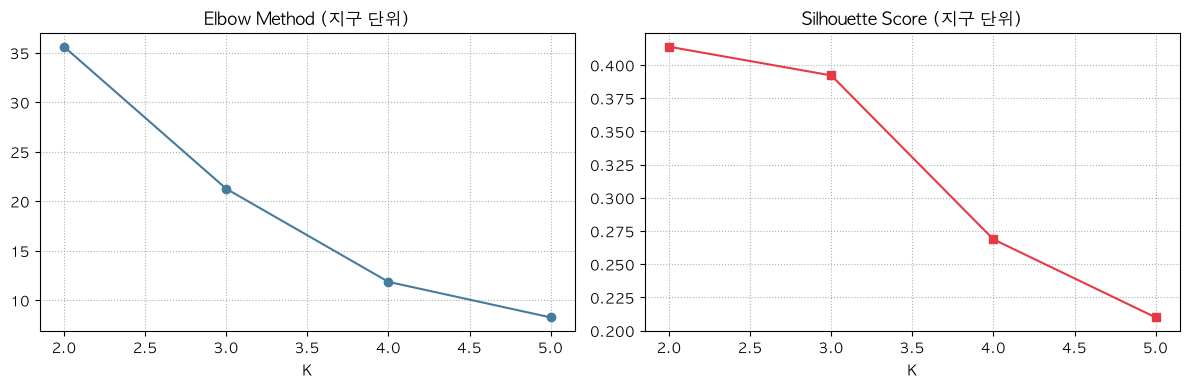

In [39]:
# 피처 표준화
X_dist = district_cluster_df[district_feature_cols]
scaler_dist = StandardScaler()
X_dist_scaled = scaler_dist.fit_transform(X_dist)

# K 탐색 (2 ~ 5)
k_range = range(2, 6)
inertia_list = []
sil_list = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_dist_scaled)
    inertia_list.append(km.inertia_)
    sil_list.append(silhouette_score(X_dist_scaled, labels))

# 실루엣 점수 및 엘보우 확인
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(k_range, inertia_list, marker='o', color='#457B9D')
ax1.set_title('Elbow Method (지구 단위)')
ax1.set_xlabel('K')
ax1.grid(True, linestyle=':')

ax2.plot(k_range, sil_list, marker='s', color='#E63946')
ax2.set_title('Silhouette Score (지구 단위)')
ax2.set_xlabel('K')
ax2.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

### 군집화 진행 (K=4)

In [40]:
# K=4 군집 모델 학습
kmeans_dist = KMeans(n_clusters=4, random_state=42, n_init=10)
district_cluster_df['cluster'] = kmeans_dist.fit_predict(X_dist_scaled)

# 군집별 주요 피처 평균 요약표
dist_summary = district_cluster_df.groupby('cluster')[district_feature_cols + ['total_capacity', 'lot_count']].mean().round(1)
dist_summary.insert(0, '지구 수', district_cluster_df['cluster'].value_counts().sort_index())

print("=== [지구 단위 군집별 핵심 특성 요약] ===")
display(dist_summary)

# 군집별 소속 지구 출력
print("\n=== [군집별 소속 지구 목록] ===")
for c in sorted(district_cluster_df['cluster'].unique()):
    districts = district_cluster_df[district_cluster_df['cluster'] == c]['DSTRCT_TYPE'].tolist()
    print(f"\n▶ 지구 군집 {c} ({len(districts)}개 지구):")
    print("  " + ", ".join(districts))

=== [지구 단위 군집별 핵심 특성 요약] ===


,지구 수,weekday_daily_cnt,weekend_daily_cnt,weekday_avg_duration,weekend_avg_duration,total_demand,turnover_rate,total_capacity,lot_count
cluster,,,,,,,,,
0,6,1102.6,1658.3,90.1,90.0,460804.3,3.5,368.5,2.2
1,1,4900.3,7009.6,205.0,112.5,2010095.0,3.1,1782.0,5.0
2,1,2216.6,2915.6,63.7,69.2,882449.0,12.7,190.0,2.0
3,3,2415.3,3731.1,115.5,103.5,1019741.3,4.1,688.3,2.7



=== [군집별 소속 지구 목록] ===

▶ 지구 군집 0 (6개 지구):
  강서, 광나루, 난지, 망원, 양화, 이촌

▶ 지구 군집 1 (1개 지구):
  여의도

▶ 지구 군집 2 (1개 지구):
  잠실

▶ 지구 군집 3 (3개 지구):
  뚝섬, 반포, 잠원


* 군집 1: 여의도 (1개 지구)
  * 수요 및 인프라 규모: 총 수요량 201만 건, 총 주차면수 1,782면(주차장 5개소)으로 모든 지표에서 압도적 1위
  * 체류 특성: 평일 평균 체류시간이 205.0분(약 3시간 25분)으로 전체 최장이며, 주말(112.5분) 대비 평일에 장기 주차가 극도로 집중
  * 회전율: 일평균 이용 건수(평일 4,900대 / 주말 7,010대)는 가장 많으나, 긴 체류시간으로 인해 면당 회전율은 3.1회로 가장 낮음

* 군집 2: 잠실 (1개 지구)
  * 회전율 및 효율성: 면당 일평균 회전율이 12.7회로 타 군집(3~4회 수준) 대비 3~4배 이상 높은 독보적 초고회전 구조
  * 체류 특성: 평일 63.7분, 주말 69.2분으로 전 군집 중 체류시간이 가장 짧음 (1시간 내외)
  * 공급 대비 수요: 주차면수는 190면(주차장 2개소)으로 가장 작으나, 빠른 입출차를 바탕으로 연간 88.2만 건의 수요를 소화

* 군집 3: 뚝섬, 반포, 잠원 (3개 지구)
  * 주말 수요 집중: 평일(2,415대) 대비 주말 일평균 이용 건수가 3,731대로 약 1.54배 증가하여 주말 유입 집중도가 가장 높음
  * 체류 특성: 평일 115.5분, 주말 103.5분으로 양일 모두 100분 이상의 장기 체류 패턴 유지
  * 규모: 지구당 평균 688.3면(주차장 2.7개소), 연간 총 수요 약 102만 건으로 여의도에 이은 대규모 여가 거점

* 군집 0: 강서, 광나루, 난지, 망원, 양화, 이촌 (6개 지구)
  * 이용 안정성: 평일 체류시간(90.1분)과 주말 체류시간(90.0분)이 거의 동일하여 요일별 이용 패턴 변화가 가장 적음
  * 수요 규모: 지구당 연간 총 수요 약 46만 건, 일평균 이용 건수(평일 1,103대 / 주말 1,658대)로 전체 군집 중 가장 완만한 수요
  * 회전율 및 인프라: 지구당 평균 368.5면(주차장 2.2개소), 면당 일평균 회전율 3.5회 수준의 표준적인 근린 생활권 특성

---

지구(DSTRCT) 단위 군집별 비가격적 운영 최적화 전략
* 지구 단위 분석에서는 한강공원 전체의 지리적·기능적 역할 차이가 뚜렷하게 드러나므로, 지구별 핵심 병목 요인(장기 통근, 초고회전, 주말 피크닉, 근린 생활)에 맞춘 맞춤형 관리 방안을 제안합니다.

1. 군집 1: 여의도 (초과밀 랜드마크 & 통근 복합형)
* 평일 통근 장기 주차 억제를 위한 공간 탄력 운영
  * 평일 체류시간(205분)이 비정상적으로 긴 만큼, 평일 08~18시에는 정기권 및 업무 목적 장기 주차를 엄격히 제한하고, 1~2개 주차장은 '단기 이용자(2시간 이내) 전용 구역'으로 지정하여 순수 공원 방문객 공간을 확보합니다.

* 진입로 실시간 사전 차단 및 광역 우회 시스템
  * 일평균 5,000~7,000대가 유입되는 상시 과밀 지역이므로, 올림픽대로·노들로 등 주요 한강 진입 나들목 전방 VMS 전광판에 잔여 주차면수를 조기 표출하여 여의도 진입 전 다른 대중교통이나 인근 대체 주차장으로 우회를 유도합니다.

* 주말 대형 축제/행사 시 셔틀 연계 및 보행자 전용화 검토
  * 벚꽃 축제, 불꽃 축제 등 피크 시즌에는 지구 내 일부 주차장을 셔틀버스·보행 전용 구역으로 전환하고, 여의도역/국회의사당역 환승 주차장과 연계한 접근성을 강화합니다.

2. 군집 2: 잠실 (초고회전 목적성 레저형)
* 초고속 입출차 인프라(무정차 패스) 전면 도입
  * 면당 회전율이 12.7회에 달해 190면 공간에 끊임없이 차가 드나들므로, 게이트 결제 대기로 인한 병목을 없애기 위해 하이패스 자동 결제 전용 게이트와 차량번호 자동인식 모바일 정산 시스템을 100% 안착시킵니다.

* 단시간 이용객 특화 안내 및 순환 동선 분리
  * 체류시간이 1시간 내외로 짧은 이용객 중심이므로, 입구와 출구 동선을 일방통행으로 단순화하여 주차장 내부의 회차 혼잡 및 보행자 접촉 사고를 방지합니다.

* 단시간 주차 편의를 위한 픽업/드롭존(Kiss & Ride) 조성
  * 픽업이나 동승자 하차 후 즉시 나가는 초단기 회차 차량을 위해 주차 구획 외곽에 '5분 이내 회차 전용 차로(드롭존)'를 별도로 구성해 불필요한 주차면 점유를 줄입니다.

3. 군집 3: 뚝섬, 반포, 잠원 (도심 피크닉·주말 여가 거점형)
* 주말 피크타임(금 저녁~일) 탄력적 가변 주차 운영
  * 주말 이용량이 평일 대비 1.5배 이상 폭증하고 텐트·피크닉 장기 체류(100분 이상)가 집중되므로, 주말 특정 시간대에 한해 둔치 통로 일방통행 지정 및 갓길 가변 주차공간을 합법적으로 개방·운영합니다.

* 분수대/잔디광장 중심 보행자 안전 펜스 및 안내 인력 집중
  * 주말 가족 단위 및 야간(달빛무지개분수 등) 인파가 집중되므로, 주차장 진출입로와 공원 보행로 사이에 가변 안전 펜스를 설치하고 모범운전자를 피크 시간대에 상시 배치합니다.

4. 군집 0: 강서, 광나루, 난지, 망원, 양화, 이촌 (중소규모 근린·생활 밀착형)

* 완전 무인 원격 관제화를 통한 운영비 절감
  * 평일/주말 체류시간(90분)과 이용량이 일정하고 안정적인 표준형 공원이므로, 현장 상주 인력을 최소화하고 6개 지구를 하나의 '원격 통합 관제 센터'로 묶어 무인 운영 효율을 극대화합니다.

* 친환경차 충전소 및 생활 편의 인프라 거점화
  * 인근 주민들의 일상적 산책 및 장기적 근린 방문이 많은 특성을 살려 완속/급속 전기차 충전 인프라를 집중 구축하고, 다둥이/임산부/어르신 등 교통약자 배려 구획을 정비합니다.

* 캠핑/생태공원 연계 차량(난지, 강서) 진입 통로 정비
  * 난지캠핑장, 강서습지생태공원 등 특수 목적 시설이 포함된 지구의 경우, 주말 입실 시간대 대형 캠핑/SUV 차량의 통행이 원활하도록 진입로 폭을 확보하고 유도 표지판을 개선합니다.

### 군집별 위치 시각화

In [41]:
# 1. 지구 군집별 색상 및 페르소나 명칭 정의
district_cluster_meta = {
    1: {'color': '#E63946', 'name': '군집 1: 초과밀 랜드마크 & 통근 복합형 (여의도)'},        # 빨강 (단독)
    2: {'color': '#F4A261', 'name': '군집 2: 초고회전 목적성 레저형 (잠실)'},                 # 주황 (단독)
    3: {'color': '#457B9D', 'name': '군집 3: 도심 피크닉·야외 여가 거점형 (뚝섬·반포·잠원)'},  # 파랑
    0: {'color': '#2A9D8F', 'name': '군집 0: 중소규모 근린·생활 밀착형 (6개 지구)'}           # 청록
}

# 2. 한강 중심부 좌표로 기본 지도 생성
hangang_center = [37.530, 126.985]
m_district = folium.Map(
    location=hangang_center,
    zoom_start=12,
    tiles='CartoDB positron',  # 마커 식별이 용이한 밝은 지도 테마
    scrollWheelZoom=False  # 마우스 스크롤 줌 비활성화
)

# 3. 지구별 중심 마커 렌더링
for _, row in district_cluster_df.iterrows():
    c_id = row['cluster']
    c_info = district_cluster_meta[c_id]
    
    # 팝업 HTML 카드 구성
    popup_html = f"""
    <div style="font-family: 'Apple SD Gothic Neo', Malgun Gothic, sans-serif; width: 240px; line-height: 1.5;">
        <h4 style="margin: 0 0 6px 0; color: {c_info['color']};">{row['DSTRCT_TYPE']} 한강공원</h4>
        <div style="font-size: 11px; color: #555; margin-bottom: 8px;"><b>{c_info['name'].split(':')[1]}</b></div>
        <hr style="border: 0; border-top: 1px solid #ddd; margin: 4px 0 8px 0;">
        <table style="font-size: 11.5px; width: 100%;">
            <tr><td><b>소속 주차장 수</b></td><td style="text-align: right;">{int(row['lot_count'])} 개소</td></tr>
            <tr><td><b>지구 총 주차면수</b></td><td style="text-align: right;">{int(row['total_capacity'])} 면</td></tr>
            <tr><td><b>연간 총 수요량</b></td><td style="text-align: right;"><b>{int(row['total_demand']):,} 건</b></td></tr>
            <tr><td><b>면당 일평균 회전율</b></td><td style="text-align: right;"><b>{row['turnover_rate']:.2f} 회/면</b></td></tr>
            <tr><td><b>평일 건당 체류시간</b></td><td style="text-align: right;">{row['weekday_avg_duration']:.1f} 분</td></tr>
            <tr><td><b>주말 건당 체류시간</b></td><td style="text-align: right;">{row['weekend_avg_duration']:.1f} 분</td></tr>
        </table>
    </div>
    """
    
    # 원 크기: 총 수요 규모에 비례 (최소 12 ~ 최대 35)
    marker_radius = 12 + (row['total_demand'] / 2010095.0) * 23
    
    folium.CircleMarker(
        location=[row['center_lat'], row['center_lot']],
        radius=marker_radius,
        color=c_info['color'],
        weight=2.5,
        fill=True,
        fill_color=c_info['color'],
        fill_opacity=0.8,
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=f"<b>{row['DSTRCT_TYPE']}</b> ({c_info['name'].split(':')[0]})"
    ).add_to(m_district)

# 4. 좌측 하단 커스텀 범례(Legend) 추가
legend_html = f"""
<div style="
    position: fixed; 
    top: 30px; right: 30px; width: 340px; height: 165px; 
    background-color: white; border:2px solid #bbb; z-index:9999; 
    font-size:12px; padding: 12px; border-radius: 8px; box-shadow: 2px 2px 6px rgba(0,0,0,0.15);
">
    <b style="font-size: 13px; color: #222;">한강공원 지구(DSTRCT) 단위 군집 분류</b><br>
    <div style="margin-top: 8px; line-height: 1.8;">
        <i style="background: {district_cluster_meta[1]['color']}; width: 12px; height: 12px; border-radius: 50%; display: inline-block; margin-right: 6px;"></i>
        {district_cluster_meta[1]['name']}<br>
        <i style="background: {district_cluster_meta[2]['color']}; width: 12px; height: 12px; border-radius: 50%; display: inline-block; margin-right: 6px;"></i>
        {district_cluster_meta[2]['name']}<br>
        <i style="background: {district_cluster_meta[3]['color']}; width: 12px; height: 12px; border-radius: 50%; display: inline-block; margin-right: 6px;"></i>
        {district_cluster_meta[3]['name']}<br>
        <i style="background: {district_cluster_meta[0]['color']}; width: 12px; height: 12px; border-radius: 50%; display: inline-block; margin-right: 6px;"></i>
        {district_cluster_meta[0]['name']}<br>
    </div>
    <div style="font-size: 10.5px; color: #777; margin-top: 6px;">* 마커 크기는 지구별 총 수요량(연간 이용 건수)에 비례</div>
</div>
"""
m_district.get_root().html.add_child(folium.Element(legend_html))

# 지도 출력
m_district

# ⚙️ 회귀 분석

In [54]:
# 1. 원본 데이터 복사 및 날짜형 변환
df_reg = df.copy()
df_reg['DT'] = pd.to_datetime(df_reg['DT'])

# 2. 날짜 기반 파생 피처 생성
df_reg['month'] = df_reg['DT'].dt.month
df_reg['dayofweek'] = df_reg['DT'].dt.dayofweek  # 0:월 ~ 6:일

# 3. 날씨 기반 파생 피처 (비 여부)
df_reg['is_rain'] = (df_reg['precip'] > 0).astype(int)

# 4. 회귀 모델에 사용할 입력 컬럼(X)과 타겟 컬럼(y) 지정
# 수치형 피처
numeric_features = ['PRK_CNT', 'temp', 'precip', 'is_weekend', 'is_holiday', 'is_rain', 'month', 'dayofweek']

# 범주형 피처 (지구)
categorical_features = ['DSTRCT_TYPE']

# 5. 범주형 변수 One-Hot Encoding 처리
# df_model = pd.get_dummies(df_reg, columns=categorical_features, drop_first=True)
df_model = df_reg.copy()

# 모델에 들어갈 최종 X 피처 목록 정의
feature_cols_reg = [col for col in df_model.columns if col not in ['DT', 'PRK_CNTOM', 'UTZTN_HR', 'PSTN_INFO_LAT', 'PSTN_INFO_LOT', 'DAY_NAME', 'DAY_OF_WEEK', 'PKLT_NM', 'DSTRCT_TYPE']]

print(f"총 데이터 수(행): {len(df_model):,}개")
print(f"독립변수(X 피처) 개수: {len(feature_cols_reg)}개")
print("사용할 피처 목록 예시:", feature_cols_reg[:10])

총 데이터 수(행): 10,220개
독립변수(X 피처) 개수: 12개
사용할 피처 목록 예시: ['PRK_CNT', 'BSC_CRG', 'INTR_CRG', 'PRVDY_CRG', 'PRD_AMT', 'is_holiday', 'temp', 'precip', 'is_weekend', 'month']


In [55]:
# 1. 날짜 순으로 정렬 후 8:2 시계열 분할
df_model_sorted = df_model.sort_values(by='DT').reset_index(drop=True)

split_idx = int(len(df_model_sorted) * 0.8)

X = df_model_sorted[feature_cols_reg]
y = df_model_sorted['PRK_CNTOM']

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"학습 데이터(Train): {len(X_train):,}건 ({df_model_sorted['DT'].iloc[0].date()} ~ {df_model_sorted['DT'].iloc[split_idx-1].date()})")
print(f"검증 데이터(Test) : {len(X_test):,}건 ({df_model_sorted['DT'].iloc[split_idx].date()} ~ {df_model_sorted['DT'].iloc[-1].date()})")

학습 데이터(Train): 8,176건 (2025-08-23 ~ 2026-06-10)
검증 데이터(Test) : 2,044건 (2026-06-11 ~ 2026-08-24)


=== [8종 회귀 모델 예측 성능 종합 벤치마크] ===


,Model,MAE (대),RMSE (대),R² (설명력)
0,LightGBM,158.09,271.71,0.8908
1,XGBoost,155.96,272.05,0.8905
2,Extra Trees,162.39,281.97,0.8824
3,Gradient Boosting,189.52,282.64,0.8818
4,Random Forest,161.63,283.45,0.8811
5,Linear Regression,549.69,679.32,0.3172
6,Ridge (L2),549.71,679.33,0.3172
7,Lasso (L1),549.76,679.34,0.3172


/var/folders/yd/3llw30vx5k3241gyl8_mwl_w0000gn/T/ipykernel_46141/3702468922.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eval_df, x='R² (설명력)', y='Model', palette='Blues_r', ax=ax1)
/var/folders/yd/3llw30vx5k3241gyl8_mwl_w0000gn/T/ipykernel_46141/3702468922.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eval_df, x='MAE (대)', y='Model', palette='Reds_r', ax=ax2)


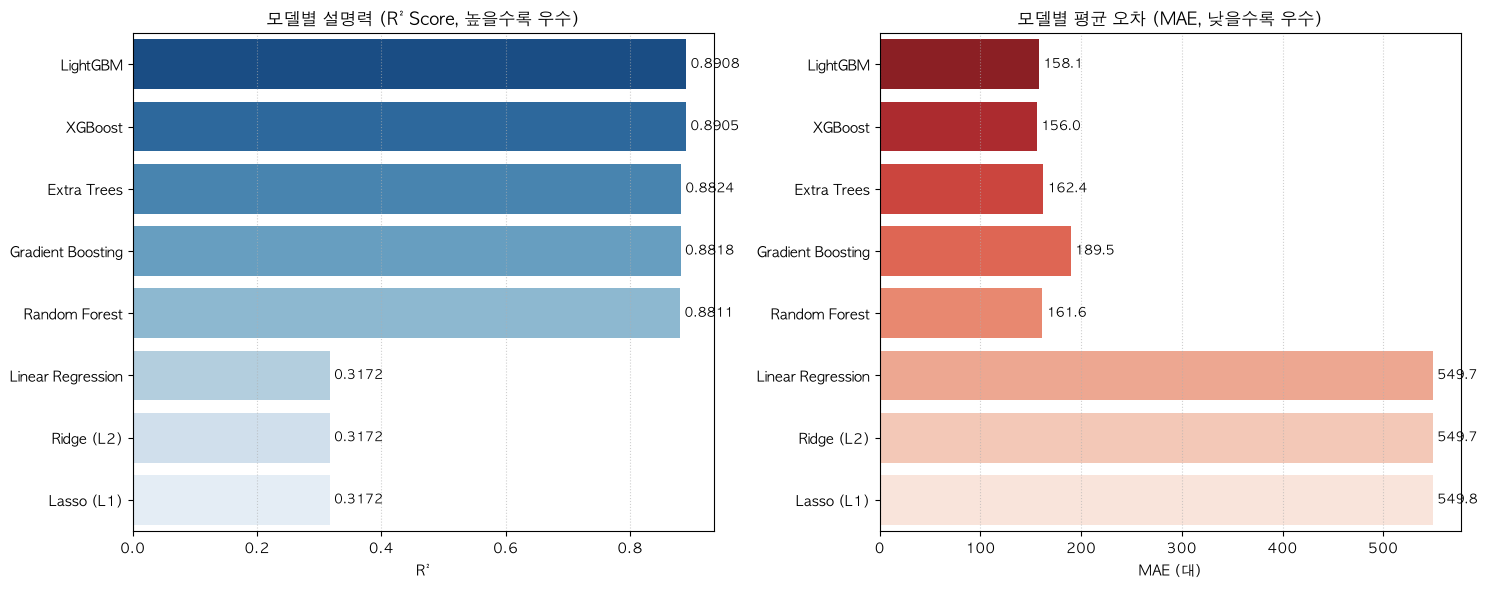

/var/folders/yd/3llw30vx5k3241gyl8_mwl_w0000gn/T/ipykernel_46141/3702468922.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')


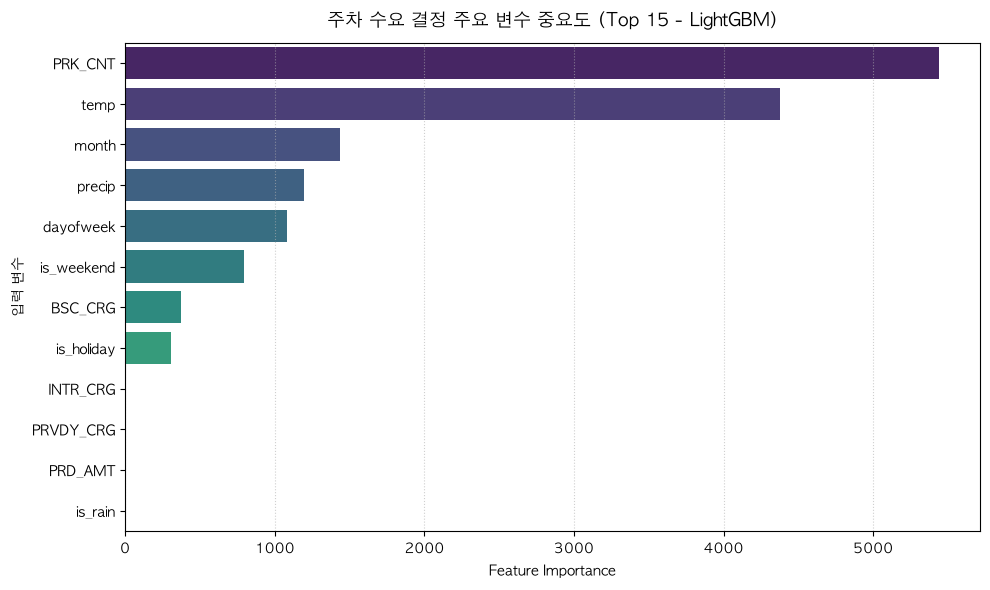

In [ ]:
# 1. 8종 회귀 모델 정의
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=1.0, random_state=42),
    'Lasso (L1)': Lasso(alpha=0.1, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
    'LightGBM': lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42, verbosity=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=42, n_jobs=-1)
}

# 2. 일괄 학습, 예측 및 평가지표 산출
results = []
predictions = {}

for name, model in models.items():
    # 모델 학습
    model.fit(X_train, y_train)
    
    # 예측 및 음수 클리핑 (주차 수요는 0 이상)
    pred = np.clip(model.predict(X_test), 0, None)
    predictions[name] = pred
    
    # 평가 지표
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    
    results.append({
        'Model': name,
        'MAE (대)': round(mae, 2),
        'RMSE (대)': round(rmse, 2),
        'R² (설명력)': round(r2, 4)
    })

# 3. 성능 비교 결과표 출력 (R² 기준 내림차순 정렬)
eval_df = pd.DataFrame(results).sort_values(by='R² (설명력)', ascending=False).reset_index(drop=True)

print("=== [8종 회귀 모델 예측 성능 종합 벤치마크] ===")
display(eval_df)

# 4. 성능 비교 막대그래프 시각화 (R² & MAE)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=eval_df, x='R² (설명력)', y='Model', palette='Blues_r', ax=ax1)
ax1.set_title('모델별 설명력 (R² Score, 높을수록 우수)', fontsize=12, fontweight='bold')
ax1.set_xlabel('R²')
ax1.set_ylabel('')
ax1.grid(axis='x', linestyle=':', alpha=0.6)

# 막대 라벨 표시
for c in ax1.containers:
    ax1.bar_label(c, fmt='%.4f', padding=3, fontsize=9)

sns.barplot(data=eval_df, x='MAE (대)', y='Model', palette='Reds_r', ax=ax2)
ax2.set_title('모델별 평균 오차 (MAE, 낮을수록 우수)', fontsize=12, fontweight='bold')
ax2.set_xlabel('MAE (대)')
ax2.set_ylabel('')
ax2.grid(axis='x', linestyle=':', alpha=0.6)

for c in ax2.containers:
    ax2.bar_label(c, fmt='%.1f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

# 5. 최우수 모델의 Feature Importance Top 15 시각화
best_model_name = eval_df.iloc[0]['Model']
best_model = models[best_model_name]

if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': feature_cols_reg,
        'importance': best_model.feature_importances_
    }).sort_values(by='importance', ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
    plt.title(f'주차 수요 결정 주요 변수 중요도 (Top 15 - {best_model_name})', fontsize=13, pad=12, fontweight='bold')
    plt.xlabel('Feature Importance', fontsize=10)
    plt.ylabel('입력 변수', fontsize=10)
    plt.grid(axis='x', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()